# Copenhagen Housing Price Model

Hierarchical Bayesian model of residential sqm prices across 9 Copenhagen districts (1992–2024), with a 2026–2060 forecast driven by Statistics Denmark population projections.

**Data sources**
- Housing transactions: [Kaggle – Danish Residential Housing Prices 1992–2024](https://www.kaggle.com/datasets/martinfrederiksen/danish-residential-housing-prices-1992-2024)
- Socioeconomic panel: Statistics Denmark (KKBEF2, KKLEDIG6, KKIND3, KKHUS1, KKFR2026)

### Table of Contents
1. [Phase 1 - Data Ingestion & EDA](#phase-1---data-ingestion--eda)
    * Task 1.1 Housing transaction data - Tomas
    * Task 1.2 & Task 1.3 Statistics Denmark - David
2. [Phase 2 - Feature Engineering](#phase-2---feature-engineering)
    * Task 2.1 Aggregate housing prices to district-year level & 2.2 Align district names & 2.3 Join housing aggregates - Ursula
    * Task 2.4 - Reduce covariates
    * Task 2.5 - Feature EDA
3. Phase 3 - PGM design
4. Phase 4 - Pyro implementation 
5. Phase 5 - Inference 
6. Phase 6 - Results & 2026-2060 forecast

### Possible Project Plan
![image.png](attachment:image.png)
![image-2.png](attachment:image-2.png)
![image-3.png](attachment:image-3.png)
![image-4.png](attachment:image-4.png)
![image-5.png](attachment:image-5.png)
![image-6.png](attachment:image-6.png)

In [3]:
import numpy as numpy
import pandas as pd
import matplotlib.pyplot as plt
import sys, pyarrow as pa
print(sys.executable)
print("pandas:", pd.__version__)
print("pyarrow:", pa.__version__)

/usr/local/bin/python3
pandas: 2.3.3
pyarrow: 23.0.1


## Phase 1 - Data Ingestion & EDA
### 1.1 Housing transaction data
Load the Kaggle parquet, filter to Copenhagen zip codes (1000–2720), and map zip codes to the 10 Copenhagen districts used by Statistics Denmark. Basic EDA: sales counts per district, price distributions, and temporal trends.

In [4]:
df = pd.read_parquet('data/DKHousingPrices.parquet', engine='pyarrow')
df['date'] = pd.to_datetime(df['date'])
print("Original shape:", df.shape)

mask = df['zip_code'].between(1000, 2720)
print("Rows matching København:", mask.sum())

df = df[mask].copy()

# Map postal codes to neighborhoods using ranges
def map_zip_to_district(zip_code):
    # Indre By (City Center)
    if 1000 <= zip_code <= 1499:
        return 'Indre By'
    
    # Østerbro
    elif zip_code in [2100, 2150]:
        return 'Østerbro'
    
    # Nørrebro
    elif 2200 <= zip_code <= 2204:
        return 'Nørrebro'
    
    # Vesterbro/Kongens Enghave (includes Sydhavn 2450)
    elif 1500 <= zip_code <= 1799 or zip_code == 2450:
        return 'Vesterbro'
    
    # Valby
    elif zip_code == 2500:
        return 'Valby'
    
    # Vanløse
    elif zip_code == 2720:
        return 'Vanløse'
    
    # Brønshøj-Husum
    elif zip_code == 2700:
        return 'Brønshøj-Husum'
    
    # Bispebjerg (includes Nordvest)
    elif 2400 <= zip_code <= 2404:
        return 'Bispebjerg'
    
    # Amager Øst & Vest
    elif zip_code == 2300:
        return 'Amager'
    
    # Frederiksberg (Separate municipality, but often grouped)
    elif zip_code == 2000 or 1800 <= zip_code <= 1999:
        return 'Frederiksberg'
        
    return None
df['neighborhood'] = df['zip_code'].apply(map_zip_to_district)

# Show unmatched postal codes
unmatched = df[df['neighborhood'].isna()]['zip_code'].unique()
if len(unmatched) > 0:
    print(f"Unmatched postal codes: {sorted(unmatched)}")

df.drop(columns=['quarter', 'house_id', 'city', 'area', 'region'], inplace=True, errors='ignore')
df.reset_index(drop=True, inplace=True)
df.head()

Original shape: (1507908, 19)
Rows matching København: 150382
Unmatched postal codes: [np.int16(2600), np.int16(2605), np.int16(2610), np.int16(2620), np.int16(2625), np.int16(2630), np.int16(2635), np.int16(2640), np.int16(2650), np.int16(2660), np.int16(2665), np.int16(2670), np.int16(2680), np.int16(2690)]


,date,house_type,sales_type,year_build,purchase_price,%_change_between_offer_and_purchase,no_rooms,sqm,sqm_price,address,zip_code,nom_interest_rate%,dk_ann_infl_rate%,yield_on_mortgage_credit_bonds%,neighborhood
0,2024-10-24,Villa,regular_sale,1997,6500000,-3.0,5,142.0,45774.648438,Spættevej 16,2680,3.1,NaN,NaN,None
1,2024-10-24,Apartment,regular_sale,2006,4115000,0.0,3,77.0,53441.558594,"Teglholmsgade 8B, 3. th",2450,3.1,NaN,NaN,Vesterbro
2,2024-10-24,Apartment,regular_sale,1885,3400000,0.0,2,46.0,73913.046875,"Jakob Dannefærds Vej 10B, 4. th",1973,3.1,NaN,NaN,Frederiksberg
3,2024-10-24,Villa,family_sale,1929,4750000,0.0,4,118.0,40254.238281,Herfølgevej 19,2700,3.1,NaN,NaN,Brønshøj-Husum
4,2024-10-23,Villa,regular_sale,1949,4550000,-4.0,4,112.0,40625.000000,Vestre Plantagevej 3,2680,3.1,NaN,NaN,None


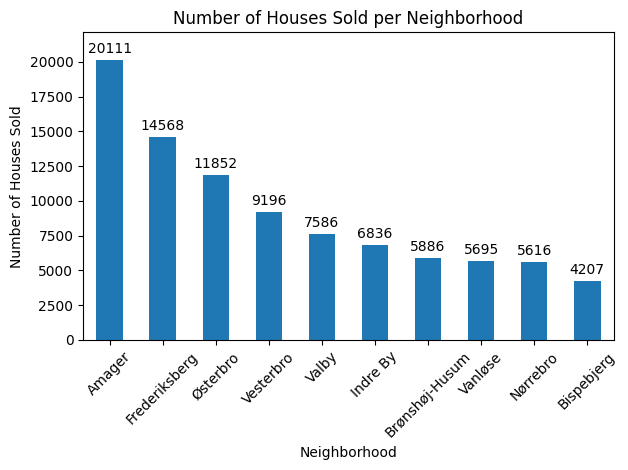

In [5]:
ax = df['neighborhood'].value_counts().plot(kind='bar')
ax.bar_label(ax.containers[0], padding=3)
plt.title('Number of Houses Sold per Neighborhood')
plt.xlabel('Neighborhood')
plt.ylabel('Number of Houses Sold')
plt.ylim(0, df['neighborhood'].value_counts().max() * 1.1)
plt.xticks(rotation=45)
plt.tight_layout()

In [6]:
df.groupby('neighborhood')['purchase_price'].agg(['mean', 'median', 'std'])

,mean,median,std
neighborhood,,,
Amager,3.274996e+06,2895000.0,2.067358e+06
Bispebjerg,2.536727e+06,2150000.0,1.626489e+06
Brønshøj-Husum,2.814610e+06,2400000.0,1.808526e+06
Frederiksberg,3.793048e+06,3300000.0,2.483333e+06
Indre By,4.280457e+06,3700000.0,2.803818e+06
Nørrebro,2.743367e+06,2469000.0,1.647398e+06
Valby,3.051307e+06,2660000.0,2.030047e+06
Vanløse,2.810252e+06,2330000.0,1.887941e+06
Vesterbro,3.956808e+06,3642085.5,2.271774e+06


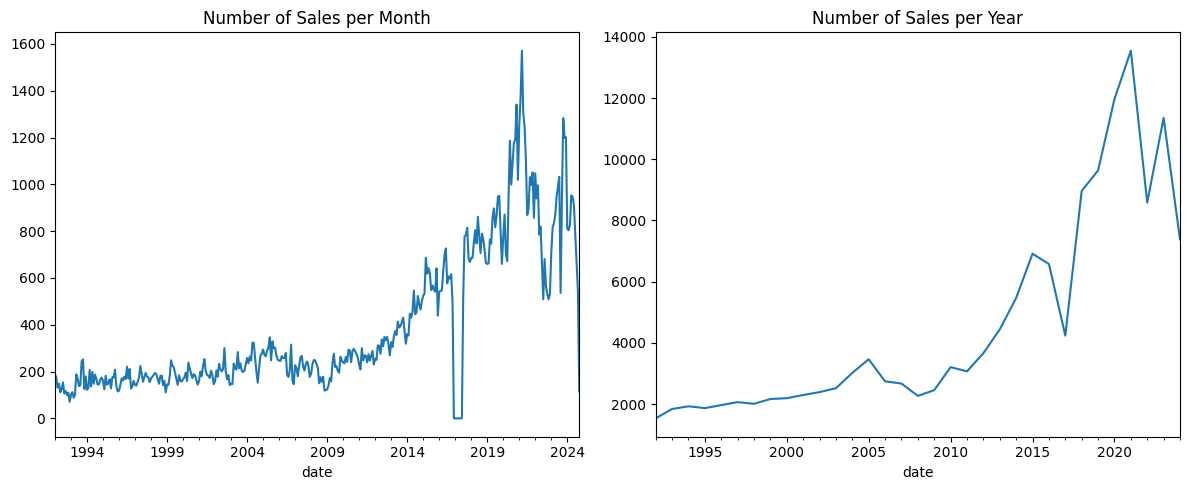

In [7]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

ts = df.set_index('date').resample('D').size()  # Daily counts of sales

# By month
ts_month = ts.resample('MS').sum()  # MS = month start
ts_month.plot(ax=axes[0])
axes[0].set_title('Number of Sales per Month')

# By year
ts_year = ts.resample('YS').sum()   # YS = year start
ts_year.plot(ax=axes[1])
axes[1].set_title('Number of Sales per Year')

plt.tight_layout()
plt.show()

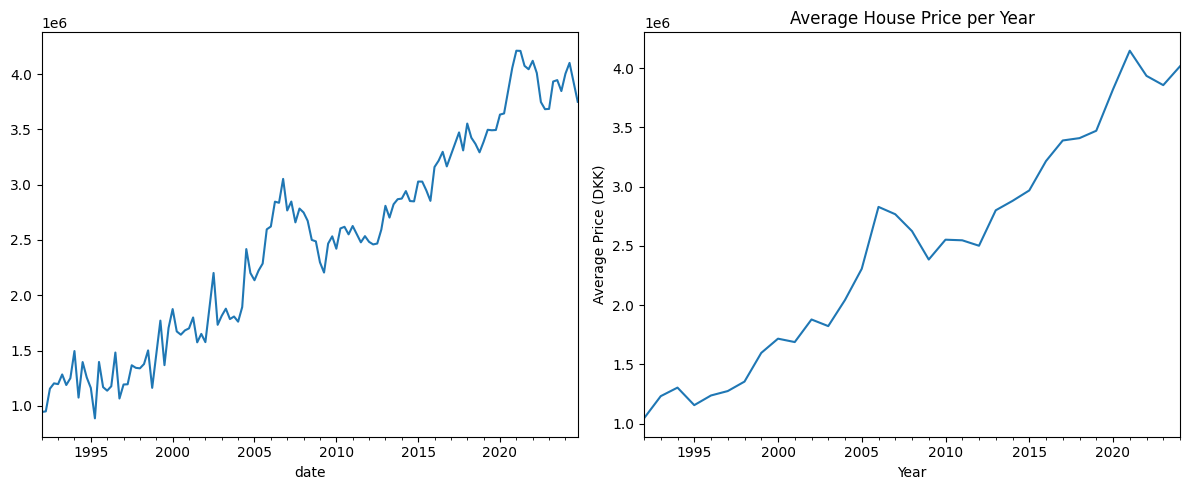

In [8]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
# Average house price per quarter
avg_price_quarter = df.groupby(df['date'].dt.to_period('Q'))['purchase_price'].mean()
avg_price_quarter.plot(ax=axes[0])
plt.title('Average House Price per Quarter')
plt.xlabel('Quarter')
plt.ylabel('Average Price (DKK)')
plt.tight_layout()



avg_price_year = df.groupby(df['date'].dt.to_period('Y'))['purchase_price'].mean()
avg_price_year.plot(ax=axes[1])
plt.title('Average House Price per Year')
plt.xlabel('Year')
plt.ylabel('Average Price (DKK)')
plt.tight_layout()
plt.show()

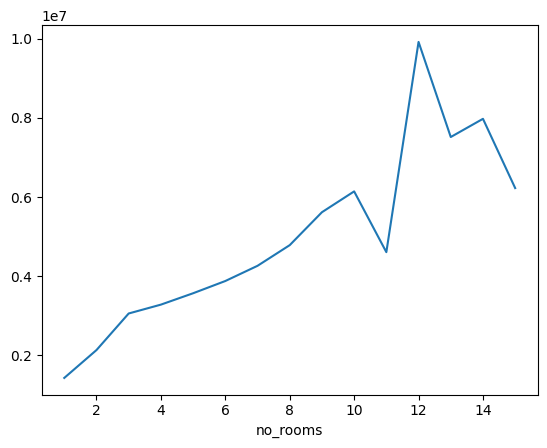

In [9]:
df.groupby('no_rooms')['purchase_price'].mean().plot();

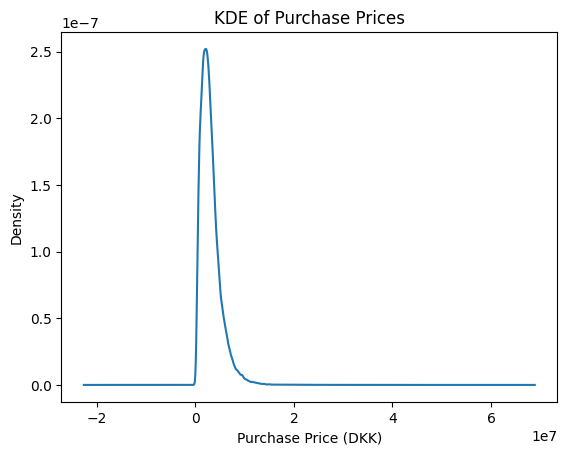

In [10]:
# KDE plot for purchase_price in 2024
df['purchase_price'].plot(kind='kde')
plt.title('KDE of Purchase Prices')
plt.xlabel('Purchase Price (DKK)')
plt.ylabel('Density')
plt.show()

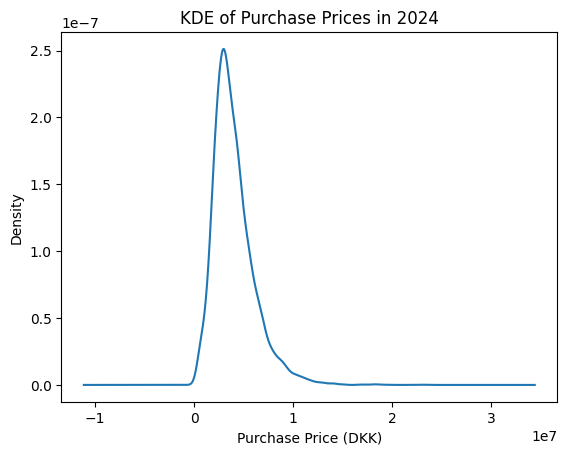

In [11]:
# KDE plot for purchase_price in 2024
df[df['date'] >= '2024-01-01']['purchase_price'].plot(kind='kde')
plt.title('KDE of Purchase Prices in 2024')
plt.xlabel('Purchase Price (DKK)')
plt.ylabel('Density')
plt.show()

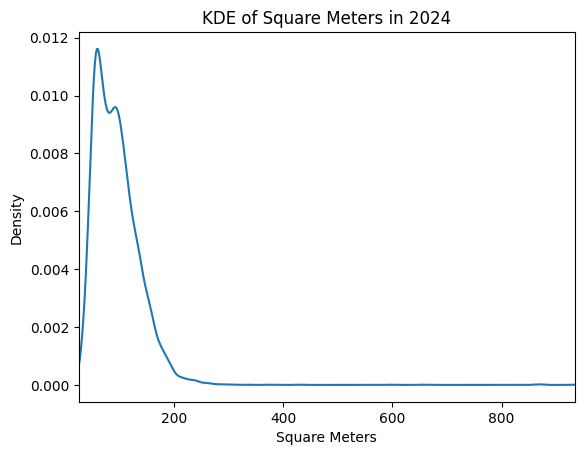

In [12]:
sqm_2024 = df[df['date'] >= '2024-01-01']['sqm']
lower, upper = sqm_2024.quantile([0, 1])
sqm_2024.plot(kind='kde')
plt.title('KDE of Square Meters in 2024')
plt.xlabel('Square Meters')
plt.ylabel('Density')
plt.xlim(lower, upper)
plt.show()

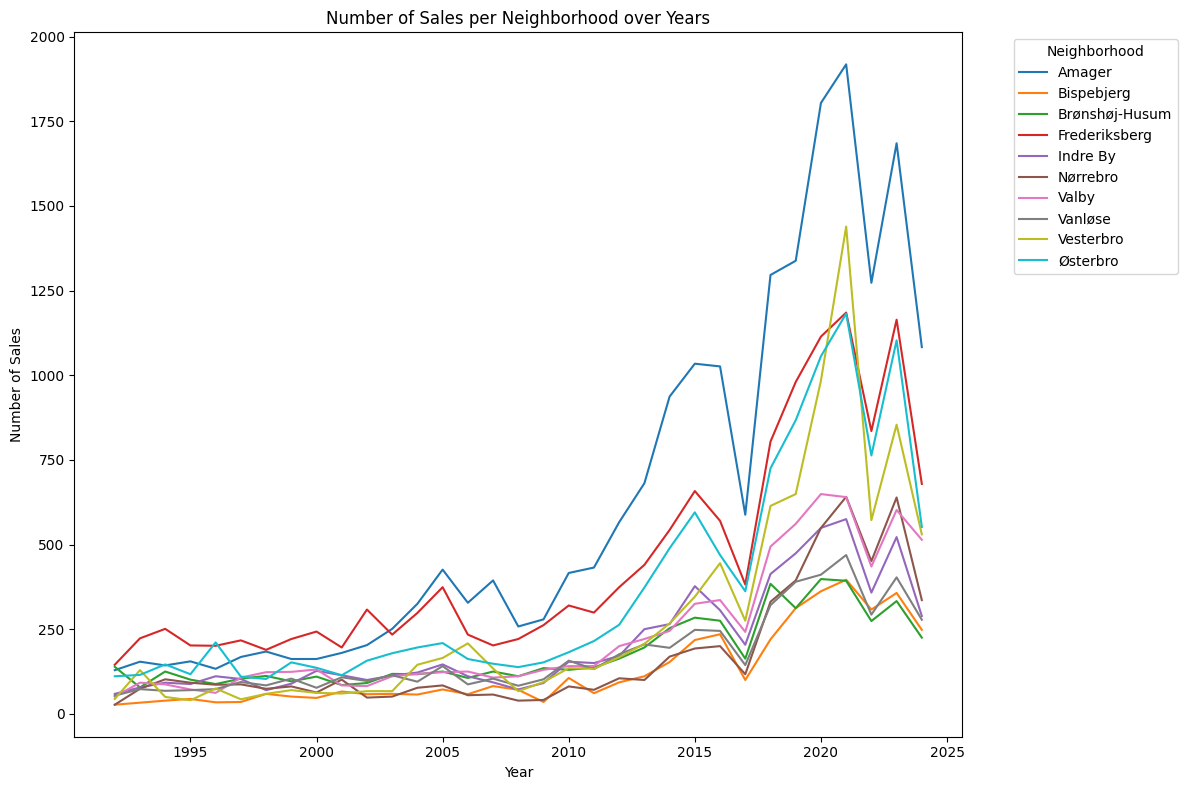

In [13]:
# Plot number of sales per neighborhood over the years
import matplotlib.pyplot as plt

# Group by year and neighborhood, count the number of sales
sales_per_year_neigh = df.groupby([df['date'].dt.year, 'neighborhood']).size().unstack()

# Plot as line chart
sales_per_year_neigh.plot(kind='line', figsize=(12, 8))
plt.title('Number of Sales per Neighborhood over Years')
plt.xlabel('Year')
plt.ylabel('Number of Sales')
plt.legend(title='Neighborhood', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 1.2 Statistics Denmark socioeconomic panel
Load five Excel cross-tables from Statistics Denmark (Statistikbanken) and reshape from wide cross-tab format to tidy long format. Run quality checks on each tidy dataset (shape, missing values, duplicate keys, value ranges).

* *HISTORICAL:*
    * *POPULATION + PERSONS OF DANISH ORIGIN VS OTHER*
    * * KKBEF2: Population by district, sex, age and ancestry (yearly data) 
    * *AMOUNT UNEMPLOYED + DEGREE OF UNEMPLOYMENT + HIGHEST EDUCATION LEVEL:*
    * * KKLEDIG6: Unemployed (yearly) by district, degree of unemployment and highest education completed (yearly data) 
    * *TYPE OF HOUSE USE, OWNERSHIP, YEAR OF COMMISSION* _?SIZE in sqm?_
    * * KBOL3: Dwellings, square meters and residents by district, ownership, year of commissioning and type of use (yearly data) 
    * *INCOME, TYPE OF INCOME*
    * * KKIND3: Income for persons (14 years +) by district, unit, sex and type of income (yearly data) 
    * *TYPE OF HOUSEHOLD, NUMBER OF CHILDREN, HOUSEHOLD SIZE*
    * * KKHUS1: Households by district, type of household, number of children in the household and household size (!!! quaterly data) 

* *FUTURE:*
    * *POPULATION PROJECTION 2026-2060*
    * * KKFR2026: Population projection 2026 by district, sex and age (yearly)

In [14]:
import pandas as pd
import numpy as np
from pathlib import Path
import re

# ============================================================
# 1) Paths
# Run from inside: mbml-cph-housing
# ============================================================
BASE = Path.cwd()

FILES = {
    "KKBEF2": BASE / "data" / "2026417213036619584456KKBEF2.xlsx",
    "KKLEDIG6": BASE / "data" / "2026417213155619584456KKLEDIG6.xlsx",
    "KKIND3": BASE / "data" / "202641721357619584456KKIND3.xlsx",
    "KKHUS1": BASE / "data" / "2026417214930619584456KKHUS1.xlsx",
    "KKFR2026": BASE / "data" / "2026417215628619584456KKFR2026.xlsx",
}

# ============================================================
# 2) File-specific layout
# These are based on the uploaded files you showed.
# ============================================================
CONFIG = {
    "KKBEF2": {
        "sheet_name": "KKBEF2",
        "header_row": 2,   # row with years
        "data_start_row": 3,
        "dim_names": ["ancestry", "age_group", "sex", "district"],
        "time_name": "year",
        "value_name": "value",
    },
    "KKLEDIG6": {
        "sheet_name": "KKLEDIG6",
        "header_row": 2,
        "data_start_row": 3,
        "dim_names": ["education", "unemployment_degree", "district"],
        "time_name": "year",
        "value_name": "value",
    },
    "KKIND3": {
        "sheet_name": "KKIND3",
        "header_row": 2,
        "data_start_row": 3,
        "dim_names": ["income_type", "sex", "unit", "district"],
        "time_name": "year",
        "value_name": "value",
    },
    "KKHUS1": {
        "sheet_name": "KKHUS1",
        "header_row": 2,   # row with quarter labels like 1998Q1
        "data_start_row": 3,
        "dim_names": ["household_size", "children_in_household", "household_type", "district"],
        "time_name": "quarter",
        "value_name": "value",
    },
    "KKFR2026": {
        "sheet_name": "KKFR2026",
        "header_row": 2,
        "data_start_row": 3,
        "dim_names": ["sex", "district", "age"],
        "time_name": "year",
        "value_name": "value",
    },
}

# ============================================================
# 3) Helpers
# ============================================================
def clean_text(x):
    """Standardize cell text while preserving real missing values."""
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    if x in {"", "nan", "None", "NA", "N/A"}:
        return np.nan
    x = re.sub(r"\s+", " ", x)
    return x

def clean_district_name(x):
    """Optional cleanup for district labels."""
    if pd.isna(x):
        return x
    x = str(x).strip()
    x = re.sub(r"^District\s*-\s*", "", x)
    return x

def parse_quarter_to_period(q):
    """
    Convert strings like 1998Q1 to pandas Period('1998Q1', freq='Q').
    If parsing fails, return original value.
    """
    if pd.isna(q):
        return np.nan
    q = str(q).strip()
    m = re.fullmatch(r"(\d{4})Q([1-4])", q)
    if m:
        year, quarter = m.groups()
        return pd.Period(f"{year}Q{quarter}", freq="Q")
    return q

def load_crosstab_excel(path, sheet_name, header_row, data_start_row, dim_names, time_name, value_name):
    """
    Read a Statistikbanken-style Excel cross table and reshape it to tidy long format.
    """
    raw = pd.read_excel(path, sheet_name=sheet_name, header=None)

    # Clean all cells lightly
    raw = raw.applymap(clean_text)

    n_dims = len(dim_names)

    # Extract time labels from header row
    time_labels = raw.iloc[header_row, n_dims:].tolist()

    # Keep only rows that contain at least one non-missing value somewhere
    data = raw.iloc[data_start_row:, :].copy()
    data = data.dropna(how="all").reset_index(drop=True)

    # Rename columns
    data.columns = dim_names + time_labels

    # Forward-fill the dimension columns only
    data[dim_names] = data[dim_names].ffill()

    # Melt to long format
    tidy = data.melt(
        id_vars=dim_names,
        var_name=time_name,
        value_name=value_name
    )

    # Remove missing values in the measure column
    tidy[value_name] = pd.to_numeric(tidy[value_name], errors="coerce")
    tidy = tidy.dropna(subset=[value_name]).reset_index(drop=True)

    # Clean dimension values
    for col in dim_names:
        tidy[col] = tidy[col].apply(clean_text)

    # District cleanup
    if "district" in tidy.columns:
        tidy["district"] = tidy["district"].apply(clean_district_name)

    # Convert time column
    if time_name == "year":
        tidy[time_name] = pd.to_numeric(tidy[time_name], errors="coerce").astype("Int64")
    elif time_name == "quarter":
        tidy[time_name] = tidy[time_name].apply(parse_quarter_to_period)

    # Final sort
    sort_cols = [c for c in dim_names + [time_name] if c in tidy.columns]
    tidy = tidy.sort_values(sort_cols).reset_index(drop=True)

    return tidy

# ============================================================
# 4) Load all files into tidy dataframes
# ============================================================
data = {}
summary = []

for name, path in FILES.items():
    cfg = CONFIG[name]

    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")

    _sdf = load_crosstab_excel(
        path=path,
        sheet_name=cfg["sheet_name"],
        header_row=cfg["header_row"],
        data_start_row=cfg["data_start_row"],
        dim_names=cfg["dim_names"],
        time_name=cfg["time_name"],
        value_name=cfg["value_name"],
    )

    data[name] = _sdf

    summary.append({
        "dataset": name,
        "rows": len(_sdf),
        "columns": len(_sdf.columns),
        "time_column": cfg["time_name"],
        "min_time": str(_sdf[cfg["time_name"]].min()) if len(_sdf) else None,
        "max_time": str(_sdf[cfg["time_name"]].max()) if len(_sdf) else None,
    })

# ============================================================
# 5) Create direct dataframe variables
# ============================================================
KKBEF2 = data["KKBEF2"]
KKLEDIG6 = data["KKLEDIG6"]
KKIND3 = data["KKIND3"]
KKHUS1 = data["KKHUS1"]
KKFR2026 = data["KKFR2026"]

# ============================================================
# 6) Print overview
# ============================================================
summary_df = pd.DataFrame(summary)
print("Tidy datasets loaded:")
print(summary_df)

print("\nKKBEF2 sample:")
print(KKBEF2.head())

print("\nKKLEDIG6 sample:")
print(KKLEDIG6.head())

print("\nKKIND3 sample:")
print(KKIND3.head())

print("\nKKHUS1 sample:")
print(KKHUS1.head())

print("\nKKFR2026 sample:")
print(KKFR2026.head())

# ============================================================
# 7) Optional: save cleaned versions
# ============================================================
output_dir = BASE / "data" / "cleaned"
output_dir.mkdir(parents=True, exist_ok=True)

KKBEF2.to_csv(output_dir / "KKBEF2_tidy.csv", index=False)
KKLEDIG6.to_csv(output_dir / "KKLEDIG6_tidy.csv", index=False)
KKIND3.to_csv(output_dir / "KKIND3_tidy.csv", index=False)
KKHUS1.to_csv(output_dir / "KKHUS1_tidy.csv", index=False)
KKFR2026.to_csv(output_dir / "KKFR2026_tidy.csv", index=False)

print(f"\nCleaned CSV files saved to: {output_dir}")

/var/folders/2w/hnlzx3jn2652kr04m9mgwt540000gp/T/ipykernel_31107/105591925.py:109: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  raw = raw.applymap(clean_text)
/var/folders/2w/hnlzx3jn2652kr04m9mgwt540000gp/T/ipykernel_31107/105591925.py:109: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  raw = raw.applymap(clean_text)
/var/folders/2w/hnlzx3jn2652kr04m9mgwt540000gp/T/ipykernel_31107/105591925.py:109: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  raw = raw.applymap(clean_text)
/var/folders/2w/hnlzx3jn2652kr04m9mgwt540000gp/T/ipykernel_31107/105591925.py:109: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  raw = raw.applymap(clean_text)
/var/folders/2w/hnlzx3jn2652kr04m9mgwt540000gp/T/ipykernel_31107/105591925.py:109: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  raw = raw.applymap(clean_text)


Tidy datasets loaded:
    dataset   rows  columns time_column min_time max_time
0    KKBEF2  23194        6        year     1986     2025
1  KKLEDIG6   4800        5        year     2008     2023
2    KKIND3  11400        6        year     1987     2024
3    KKHUS1  76800        6     quarter   1998Q1   2024Q4
4  KKFR2026  70000        5        year     2026     2060

KKBEF2 sample:
                            ancestry   age_group  sex     district  year  \
0  Descendants of non-western origin  0-10 years  Men  Amager Vest  1986   
1  Descendants of non-western origin  0-10 years  Men  Amager Vest  1987   
2  Descendants of non-western origin  0-10 years  Men  Amager Vest  1988   
3  Descendants of non-western origin  0-10 years  Men  Amager Vest  1989   
4  Descendants of non-western origin  0-10 years  Men  Amager Vest  1990   

   value  
0  109.0  
1  136.0  
2  163.0  
3  168.0  
4  189.0  

KKLEDIG6 sample:
                           education unemployment_degree     district  ye

In [15]:
import pandas as pd

# Assumes these already exist from your load script:
# data, KKBEF2, KKLEDIG6, KKIND3, KKHUS1, KKFR2026

datasets = {
    "KKBEF2": KKBEF2,
    "KKLEDIG6": KKLEDIG6,
    "KKIND3": KKIND3,
    "KKHUS1": KKHUS1,
    "KKFR2026": KKFR2026,
}

for name, _sdf in datasets.items():
    print("=" * 80)
    print(f"{name}")
    print("=" * 80)

    print("\nShape:")
    print(_sdf.shape)

    print("\nColumns:")
    print(_sdf.columns.tolist())

    print("\nDtypes:")
    print(_sdf.dtypes)

    print("\nMissing values per column:")
    print(_sdf.isna().sum())

    print("\nExact duplicate rows:")
    print(_sdf.duplicated().sum())

    # Identify value and time columns
    value_col = "value"
    time_col = "quarter" if "quarter" in _sdf.columns else "year"

    # Dimension columns = everything except time and value
    dim_cols = [c for c in _sdf.columns if c not in [time_col, value_col]]

    print("\nDimension columns:")
    print(dim_cols)

    print("\nNumber of duplicated keys (same dimensions + same time):")
    print(_sdf.duplicated(subset=dim_cols + [time_col]).sum())

    print("\nValue summary:")
    print(_sdf[value_col].describe())

    print("\nNegative values count:")
    print((_sdf[value_col] < 0).sum())

    print("\nSample rows:")
    print(_sdf.head(10))

    print("\nUnique values per dimension column (first 15 shown):")
    for col in dim_cols:
        uniques = _sdf[col].dropna().unique()
        print(f"\n- {col}: {len(uniques)} unique")
        print(list(uniques[:15]))

    print("\nTime column summary:")
    print("Type:", _sdf[time_col].dtype)
    print("Min:", _sdf[time_col].min())
    print("Max:", _sdf[time_col].max())

    # Check if every key-time combination appears only once
    group_sizes = _sdf.groupby(dim_cols + [time_col]).size()
    bad_groups = group_sizes[group_sizes > 1]

    print("\nNumber of key-time combinations appearing more than once:")
    print(len(bad_groups))

    if len(bad_groups) > 0:
        print("\nFirst 10 duplicated key-time combinations:")
        print(bad_groups.head(10))

    print("\n")

KKBEF2

Shape:
(23194, 6)

Columns:
['ancestry', 'age_group', 'sex', 'district', 'year', 'value']

Dtypes:
ancestry      object
age_group     object
sex           object
district      object
year           Int64
value        float64
dtype: object

Missing values per column:
ancestry     0
age_group    0
sex          0
district     0
year         0
value        0
dtype: int64

Exact duplicate rows:
0

Dimension columns:
['ancestry', 'age_group', 'sex', 'district']

Number of duplicated keys (same dimensions + same time):
0

Value summary:
count    23194.000000
mean       906.619298
std       1484.900458
min          0.000000
25%         49.000000
50%        219.000000
75%       1096.000000
max      11420.000000
Name: value, dtype: float64

Negative values count:
0

Sample rows:
                            ancestry   age_group  sex     district  year  \
0  Descendants of non-western origin  0-10 years  Men  Amager Vest  1986   
1  Descendants of non-western origin  0-10 years  Men  Amage

In [16]:
for name, _sdf in datasets.items():
    time_col = "quarter" if "quarter" in _sdf.columns else "year"
    print(name, "->", _sdf[time_col].isna().sum(), "missing time values")

KKBEF2 -> 0 missing time values
KKLEDIG6 -> 0 missing time values
KKIND3 -> 0 missing time values
KKHUS1 -> 0 missing time values
KKFR2026 -> 0 missing time values


### 1.3 Build historical panel
Pivot each tidy dataset to wide format (district × year) and outer-merge into a single historical panel (1986–2025). Quarterly KKHUS1 household data is averaged to annual frequency before pivoting. The future population projections (KKFR2026, 2026–2060) are kept as a separate panel for use in Phase 6 forecasting.

In [17]:
import pandas as pd
import numpy as np
from pathlib import Path

# ============================================================
# Assumes these already exist from your tidy import script:
# KKBEF2, KKLEDIG6, KKIND3, KKHUS1, KKFR2026
# ============================================================

# ============================================================
# 1) Helpers
# ============================================================
def safe_slug(x):
    x = str(x).strip().lower()
    x = x.replace("&", "and")
    x = x.replace("%", "pct")
    x = x.replace("/", "_")
    x = x.replace("-", "_")
    x = x.replace(",", "")
    x = x.replace(".", "")
    x = x.replace("(", "")
    x = x.replace(")", "")
    x = x.replace(":", "")
    x = x.replace("'", "")
    x = x.replace('"', "")
    x = "_".join(x.split())
    while "__" in x:
        x = x.replace("__", "_")
    return x

def flatten_columns(columns):
    flat = []
    for col in columns:
        if isinstance(col, tuple):
            parts = [safe_slug(c) for c in col if c not in [None, "", "nan"]]
            flat.append("_".join(parts))
        else:
            flat.append(safe_slug(col))
    return flat

def make_wide(_sdf, id_cols, category_cols, value_col, prefix):
    """
    Converts tidy long _sdf into district-year wide format.
    """
    out = _sdf.copy()

    # Ensure clean types
    out = out.dropna(subset=id_cols + category_cols + [value_col]).copy()

    # Pivot to wide
    wide = out.pivot_table(
        index=id_cols,
        columns=category_cols,
        values=value_col,
        aggfunc="sum"
    ).reset_index()

    # Flatten multiindex columns
    wide.columns = id_cols + [
        f"{prefix}_" + "_".join([safe_slug(x) for x in col]) if isinstance(col, tuple) else f"{prefix}_{safe_slug(col)}"
        for col in wide.columns[len(id_cols):]
    ]

    return wide

# ============================================================
# 2) Standardize district/year formats
# ============================================================
KKBEF2 = KKBEF2.copy()
KKLEDIG6 = KKLEDIG6.copy()
KKIND3 = KKIND3.copy()
KKHUS1 = KKHUS1.copy()
KKFR2026 = KKFR2026.copy()

for _sdf in [KKBEF2, KKLEDIG6, KKIND3, KKHUS1, KKFR2026]:
    if "district" in _sdf.columns:
        _sdf["district"] = _sdf["district"].astype(str).str.strip()

if "year" in KKBEF2.columns:
    KKBEF2["year"] = pd.to_numeric(KKBEF2["year"], errors="coerce").astype("Int64")
if "year" in KKLEDIG6.columns:
    KKLEDIG6["year"] = pd.to_numeric(KKLEDIG6["year"], errors="coerce").astype("Int64")
if "year" in KKIND3.columns:
    KKIND3["year"] = pd.to_numeric(KKIND3["year"], errors="coerce").astype("Int64")
if "year" in KKFR2026.columns:
    KKFR2026["year"] = pd.to_numeric(KKFR2026["year"], errors="coerce").astype("Int64")

# Convert quarter -> year for housing
if "quarter" in KKHUS1.columns:
    if str(KKHUS1["quarter"].dtype) == "period[Q-DEC]":
        KKHUS1["year"] = KKHUS1["quarter"].dt.year.astype("Int64")
    else:
        KKHUS1["year"] = (
            KKHUS1["quarter"]
            .astype(str)
            .str.extract(r"(\d{4})", expand=False)
            .pipe(pd.to_numeric, errors="coerce")
            .astype("Int64")
        )

# ============================================================
# 3) Aggregate quarterly housing to annual mean
# ============================================================
KKHUS1_yearly = (
    KKHUS1
    .groupby(["household_size", "children_in_household", "household_type", "district", "year"], as_index=False)["value"]
    .mean()
)

# ============================================================
# 4) Pivot each dataset to district-year wide format
# ============================================================
KKBEF2_wide = make_wide(
    _sdf=KKBEF2,
    id_cols=["district", "year"],
    category_cols=["ancestry", "age_group", "sex"],
    value_col="value",
    prefix="pop"
)

KKLEDIG6_wide = make_wide(
    _sdf=KKLEDIG6,
    id_cols=["district", "year"],
    category_cols=["education", "unemployment_degree"],
    value_col="value",
    prefix="unemp"
)

KKIND3_wide = make_wide(
    _sdf=KKIND3,
    id_cols=["district", "year"],
    category_cols=["income_type", "sex", "unit"],
    value_col="value",
    prefix="income"
)

KKHUS1_wide = make_wide(
    _sdf=KKHUS1_yearly,
    id_cols=["district", "year"],
    category_cols=["household_size", "children_in_household", "household_type"],
    value_col="value",
    prefix="housing"
)

KKFR2026_wide = make_wide(
    _sdf=KKFR2026,
    id_cols=["district", "year"],
    category_cols=["sex", "age"],
    value_col="value",
    prefix="proj_pop"
)

# ============================================================
# 5) Merge historical datasets
# Use outer merge to keep all district-year combinations
# ============================================================
historical_panel = KKBEF2_wide.merge(
    KKLEDIG6_wide, on=["district", "year"], how="outer"
).merge(
    KKIND3_wide, on=["district", "year"], how="outer"
).merge(
    KKHUS1_wide, on=["district", "year"], how="outer"
)

historical_panel = historical_panel.sort_values(["district", "year"]).reset_index(drop=True)

# ============================================================
# 6) Keep future population projections separate
# Since only KKFR2026 covers future years
# ============================================================
future_population_panel = KKFR2026_wide.sort_values(["district", "year"]).reset_index(drop=True)

# ============================================================
# 7) Optional combined panel
# This appends future projections to historical data structure
# Most future columns will be NaN except projected population
# ============================================================
combined_panel = historical_panel.merge(
    future_population_panel, on=["district", "year"], how="outer"
).sort_values(["district", "year"]).reset_index(drop=True)

# ============================================================
# 8) Diagnostics
# ============================================================
print("=" * 80)
print("HISTORICAL PANEL")
print("=" * 80)
print("Shape:", historical_panel.shape)
print("Years:", historical_panel["year"].min(), "to", historical_panel["year"].max())
print("Districts:", historical_panel["district"].nunique())
print("Duplicated district-year rows:", historical_panel.duplicated(subset=["district", "year"]).sum())
print(historical_panel.head())

print("\n" + "=" * 80)
print("FUTURE POPULATION PANEL")
print("=" * 80)
print("Shape:", future_population_panel.shape)
print("Years:", future_population_panel["year"].min(), "to", future_population_panel["year"].max())
print("Districts:", future_population_panel["district"].nunique())
print("Duplicated district-year rows:", future_population_panel.duplicated(subset=["district", "year"]).sum())
print(future_population_panel.head())

print("\n" + "=" * 80)
print("COMBINED PANEL")
print("=" * 80)
print("Shape:", combined_panel.shape)
print("Years:", combined_panel["year"].min(), "to", combined_panel["year"].max())
print("Districts:", combined_panel["district"].nunique())
print("Duplicated district-year rows:", combined_panel.duplicated(subset=["district", "year"]).sum())
print(combined_panel.head())

# ============================================================
# 9) Save outputs
# ============================================================
BASE = Path.cwd()
output_dir = BASE / "data" / "cleaned"
output_dir.mkdir(parents=True, exist_ok=True)

historical_panel.to_csv(output_dir / "historical_panel_merged.csv", index=False)
future_population_panel.to_csv(output_dir / "future_population_panel.csv", index=False)
combined_panel.to_csv(output_dir / "combined_panel_with_future_population.csv", index=False)

print(f"\nSaved to: {output_dir}")
print("- historical_panel_merged.csv")
print("- future_population_panel.csv")
print("- combined_panel_with_future_population.csv")

HISTORICAL PANEL
Shape: (400, 212)
Years: 1986 to 2025
Districts: 10
Duplicated district-year rows: 0
      district  year  pop_descendants_of_non_western_origin_0_10_years_men  \
0  Amager Vest  1986                                              109.0      
1  Amager Vest  1987                                              136.0      
2  Amager Vest  1988                                              163.0      
3  Amager Vest  1989                                              168.0      
4  Amager Vest  1990                                              189.0      

   pop_descendants_of_non_western_origin_0_10_years_women  \
0                                              129.0        
1                                              143.0        
2                                              154.0        
3                                              182.0        
4                                              185.0        

   pop_descendants_of_non_western_origin_10_19_years_men  \
0 

## Phase 2 - Feature Engineering
Goal - Transform raw inputs into the district × year panel that feeds the Pyro model

### 2.1 Aggregate housing prices to district-year level

The housing dataset contains one row per *transaction*. The Bayesian model needs one representative
price signal per *district per year*. The cell below collapses ~91,000 regular-sale transactions
into a compact panel.

### Section 2.1: Target Variable Design (Median Log SQM Price)

In this phase, we aggregate raw transaction data into a robust target variable suitable for Bayesian modeling. The following design choices ground our approach:

* **Price per Square Meter ($sqm\_price$):** Normalizes for property size, allowing the model to compare the intrinsic value of different locations regardless of whether they feature small studios or large houses.
* **Median Aggregation:** We use the median rather than the mean to provide robustness against extreme outliers and luxury sales, ensuring the target reflects the "typical" market value of a district.
* **Log-Transformation ($log\_sqm\_price$):** This choice satisfies the **Gaussian likelihood** assumption of our observation model ($y_{dt} \sim Normal(\mu, \sigma)$). It also transforms skewed price distributions into more symmetric ones and improves numerical stability during inference.
* **Heteroskedastic Noise ($\sigma_{obs}$):** We calculate the standard deviation of log-prices (`std_log_sqm_price`) for each district-year. In the Pyro model, this is treated as **observed noise**, allowing the model to weigh consistent market years more heavily than highly volatile ones.

**Design choices:**

| Choice | Reason |
|---|---|
| **Regular sales only** | Family sales (`family_sale`) are transfers between relatives at below-market prices — they reflect family agreements, not the market. Auctions and other sale types have different dynamics. Including them would bias the price signal downward and add noise. |
| **`log(sqm_price)` before aggregating** | Housing prices are right-skewed and span roughly 5× across districts. The log transformation makes the distribution approximately Gaussian and matches the **log-normal likelihood** the Pyro model will use. `median(log(x)) = log(median(x))` by monotonicity of log, so the two orderings are equivalent for the median. |
| **Median, not mean** | The median is robust to the occasional extreme transaction (luxury penthouses, distressed sales) that would pull the mean upward. |
| **`std_log_sqm_price` (within-cell std)** | Measures how *consistent* prices are within a district-year cell. A cell with high variance (few transactions or mixed property types) carries more measurement uncertainty. In Pyro this becomes **σ_obs** — the observation noise, giving data-informed weights: cells with consistent prices constrain the posterior more tightly than cells with scattered prices. |
| **`n_transactions`** | Sample size per cell. Small-n cells (< 10 transactions) produce unreliable medians and inflated standard deviations. Flagged in the diagnostics below. |
| **`pct_change_median`** | Median percentage change between listing price and final purchase price. A proxy for *market tightness*: negative = buyer's market (sellers discount), positive = seller's market (bidding wars). Useful as a model covariate, but may correlate with the interest rate already

In [18]:
# IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

Shape: (330, 9)

Year coverage per district:
                 min   max  count
district                         
Amager          1992  2024     33
Bispebjerg      1992  2024     33
Brønshøj-Husum  1992  2024     33
Frederiksberg   1992  2024     33
Indre By        1992  2024     33
Nørrebro        1992  2024     33
Valby           1992  2024     33
Vanløse         1992  2024     33
Vesterbro       1992  2024     33
Østerbro        1992  2024     33

District-years with fewer than 10 transactions:
Empty DataFrame
Columns: [district, year, median_log_sqm_price, mean_log_sqm_price, std_log_sqm_price, n_transactions, median_sqm, median_purchase_price, pct_change_median]
Index: []


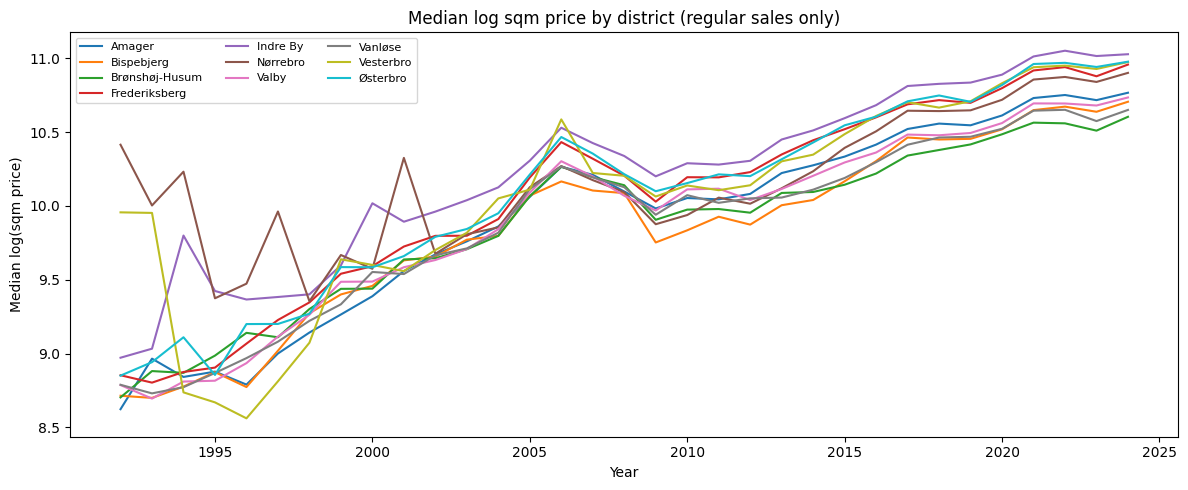


Saved: data/cleaned/housing_agg_district_year.csv


In [19]:
# Adding a filter for regular sales only, mapped district, and valid sqm_price
mask = (
    df['neighborhood'].notna() & 
    (df['sales_type'] == 'regular_sale') &
    df['sqm_price'].notna() &
    (df['sqm_price'] > 0)
) 

# Apply the filter to the dataframe
df_filtered = df[mask].copy()

df_filtered['year']= df_filtered['date'].dt.year # Extract year from date for aggregation
df_filtered['log_sqm_price'] = np.log(df_filtered['sqm_price']) # Take log of sqm_price for modeling, satisfying gaussian likelihood assumption

# Aggregate to district × year level
housing_agg = (
    df_filtered.groupby(['neighborhood', 'year'])
    .agg(
        median_log_sqm_price   = ('log_sqm_price', 'median'), # getting the median log sqm price for each district-year, this is our main target variable for modeling
        mean_log_sqm_price     = ('log_sqm_price', 'mean'),
        std_log_sqm_price      = ('log_sqm_price', 'std'), 
        n_transactions        = ('sqm_price', 'count'), 
        median_sqm            = ('sqm', 'median'),
        median_purchase_price = ('purchase_price', 'median'),
        pct_change_median     = ('%_change_between_offer_and_purchase', 'median')
    )
    .reset_index() # Convert back to DataFrame from groupby object
    .rename(columns={'neighborhood': 'district'}) # Rename for consistency with other datasets
)

# Observing the shape and coverage of the aggregated data
print("Shape:", housing_agg.shape)
print("\nYear coverage per district:")
print(housing_agg.groupby('district')['year'].agg(['min', 'max', 'count'])) 
print("\nDistrict-years with fewer than 10 transactions:")
print(housing_agg[housing_agg['n_transactions'] < 10])

# Visual check of median log sqm price trends by district
fig, ax = plt.subplots(figsize=(12, 5))
for dist, grp in housing_agg.groupby('district'):
    ax.plot(grp['year'], grp['median_log_sqm_price'], label=dist, linewidth=1.5)
ax.set_title('Median log sqm price by district (regular sales only)')
ax.set_xlabel('Year')
ax.set_ylabel('Median log(sqm price)')
ax.legend(fontsize=8, ncol=3)
plt.tight_layout()
plt.show()

housing_agg.to_csv('data/cleaned/housing_agg_district_year.csv', index=False)
print("\nSaved: data/cleaned/housing_agg_district_year.csv")

### 2.2 Align district names and collapse Amager sub-districts

Before the two datasets can be joined, their district names must match exactly.
The housing dataset uses simplified informal names (from the zip-code mapping);
Statistics Denmark uses official administrative names.

Three issues to resolve:

1. **`Vesterbro` → `Vesterbro/Kongens Enghave`** — the full administrative name includes Kongens Enghave
2. **Drop `Frederiksberg`** — Frederiksberg is an independent municipality
3. **Collapse `Amager Øst` + `Amager Vest` → `Amager`** — zip code 2300 spans both sub-districts. We aggregate the two Statistics Denmark rows into one by summing. Summing is correct because all panel columns are count-type totals (population headcounts, unemployment counts, income totals in DKK 1,000). Per-capita derived features (e.g. income per capita) will be computed as `sum(income) / sum(population)` in Phase 2.4, which gives the correct combined-district average.

In [20]:
# Load the historical panel (socioeconomic features from Statistikbanken) that we created in Phase 1 
historical_panel = pd.read_csv('data/cleaned/historical_panel_merged.csv')

print("Aggrigated housing data districts:   ", sorted(housing_agg['district'].unique()))
print("Historical socioeconomic panel districts: ", sorted(historical_panel['district'].unique()))

# -- Part 1: rename districts in housing_agg to match historical_panel
# Vesterbro → matches panel name; Amager stays as-is (we fix the panel side)
housing_agg['district'] = housing_agg['district'].replace(
    {'Vesterbro': 'Vesterbro/Kongens Enghave'}
)
# Frederiksberg is a separate municipality — not in Statistics Denmark tables -> drop it from housing_agg
housing_agg = housing_agg[housing_agg['district'] != 'Frederiksberg'].copy() 

# -- Part 2: sum Amager Øst & Vest in the panel to match the housing data (which has them combined as Amager)
#  # zip 2300 covers both sub-districts, so housing transactions cannot be split)
# All panel columns are count-type → sum is the correct aggregation.
amager_rows = historical_panel[historical_panel['district'].isin(['Amager Øst', 'Amager Vest'])]
amager_combined = (
    amager_rows
    .drop(columns=['district']) # drop old district column
    .groupby('year', as_index=False) # group by year to sum the two sub-districts
    .sum(numeric_only=True) # sum only numeric columns, keep 'year' as-is
)
amager_combined.insert(0, 'district', 'Amager') # add new district column with combined name

# Drop old rows and append combined Amager
historical_panel = pd.concat([
    historical_panel[~historical_panel['district'].isin(['Amager Øst', 'Amager Vest'])],
    amager_combined
], ignore_index=True).sort_values(['district', 'year']).reset_index(drop=True)

# -- Verify final district alignment
agg_dists = set(housing_agg['district'].unique())
panel_dists = set(historical_panel['district'].unique())
unmatched = agg_dists.symmetric_difference(panel_dists)

if unmatched:
    print("\nWarning: Unmatched districts after cleaning:", unmatched)
else:
    print("\nSuccess: Districts are aligned between datasets.")

# Save the cleaned historical panel for modeling
housing_agg.to_csv('data/cleaned/housing_agg_district_year.csv', index=False)
historical_panel.to_csv('data/cleaned/historical_panel_merged_aligned.csv', index=False)
print("\nSaved: housing_agg_district_year.csv  (aligned)")
print("Saved: historical_panel_merged_aligned.csv")

Aggrigated housing data districts:    ['Amager', 'Bispebjerg', 'Brønshøj-Husum', 'Frederiksberg', 'Indre By', 'Nørrebro', 'Valby', 'Vanløse', 'Vesterbro', 'Østerbro']
Historical socioeconomic panel districts:  ['Amager Vest', 'Amager Øst', 'Bispebjerg', 'Brønshøj-Husum', 'Indre By', 'Nørrebro', 'Valby', 'Vanløse', 'Vesterbro/Kongens Enghave', 'Østerbro']

Success: Districts are aligned between datasets.

Saved: housing_agg_district_year.csv  (aligned)
Saved: historical_panel_merged_aligned.csv


### 2.3 Join housing aggregates with the socioeconomic panel

Merge the district-year housing aggregates with the Statistics Denmark historical panel
on the composite key `(district, year)` using an **inner join** — only district-years that
appear in *both* datasets are kept.

**Two output versions are produced:**

| Version | Years | Rows | Purpose |
|---|---|---|---|
| `model_panel_full` | all available (~1992–2024) | ~297 | Reference; some columns are NaN before 2008 |
| `model_panel_restricted` | 2008–2024 | ~153 | **Used for Pyro model fitting** — all covariate groups complete |

The 2008 cutoff is driven by KKLEDIG6 (unemployment by education level), which Statistics Denmark
only provides from 2008 onward.

**IF WE WANT TO INCLUDE A LONGER TIME-FRAME -> WE CAN TAKE UNEMPLOYMENT OUT**

Modeling panel shape: (297, 219)

Modeling panel year coverage per district:
                            min   max  count
district                                    
Amager                     1992  2024     33
Bispebjerg                 1992  2024     33
Brønshøj-Husum             1992  2024     33
Indre By                   1992  2024     33
Nørrebro                   1992  2024     33
Valby                      1992  2024     33
Vanløse                    1992  2024     33
Vesterbro/Kongens Enghave  1992  2024     33
Østerbro                   1992  2024     33

Nulls in key columns:
district                0
year                    0
median_log_sqm_price    0
n_transactions          0
dtype: int64


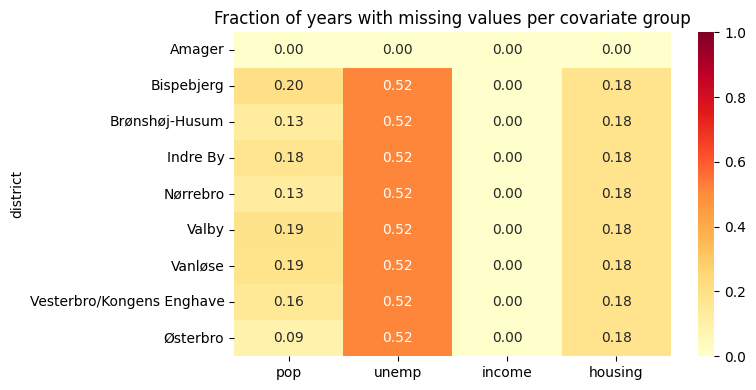


Full panel:        297 rows, years 1992–2024
Restricted panel:  153 rows, years 2008–2024


In [21]:
# Creating combined dataset for modelling 
# -- Inner join on district * year to keep only rows where we have both housing and socioeconomic data -- 
model_panel = housing_agg.merge(historical_panel, on=['district', 'year'], how='inner')

# Check the shape and coverage of the final modeling panel
print("Modeling panel shape:", model_panel.shape)
print("\nModeling panel year coverage per district:")
print(model_panel.groupby('district')['year'].agg(['min', 'max', 'count']))
print("\nNulls in key columns:")
print(model_panel[['district', 'year', 'median_log_sqm_price', 'n_transactions']].isnull().sum())

# Missing values by covariate group 
#   (we want to check if missingness is concentrated in certain districts or years, which could bias our model)
prefixes = ['pop', 'unemp', 'income', 'housing']
covariate_cols = [col for col in model_panel.columns if any(col.startswith(p) for p in prefixes)]

miss_frac = model_panel.groupby('district')[covariate_cols].apply(lambda df: df.isnull().mean())

miss_by_prefix = {}
for pfx in prefixes:
    cols = [col for col in covariate_cols if col.startswith(pfx)]
    if cols:
        miss_by_prefix[pfx.rstrip('_')] = miss_frac[cols].mean(axis=1)

miss_summary = pd.DataFrame(miss_by_prefix)

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(miss_summary, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, vmin=0, vmax=1)
ax.set_title('Fraction of years with missing values per covariate group')
plt.tight_layout()
plt.show()

# ── Two panel versions ────────────────────────────────────────────────────────
# Full panel: all available years (unemp_ columns will be NaN before 2008)
# Restricted: year >= 2008 — all covariate groups complete, used for model fitting
model_panel_full       = model_panel.copy()
model_panel_restricted = model_panel[model_panel['year'] >= 2008].copy()

model_panel_full.to_csv('data/cleaned/model_panel_full.csv', index=False)
model_panel_restricted.to_csv('data/cleaned/model_panel_restricted.csv', index=False)

print(f"\nFull panel:       {model_panel_full.shape[0]:4d} rows, "
      f"years {model_panel_full['year'].min()}–{model_panel_full['year'].max()}")
print(f"Restricted panel: {model_panel_restricted.shape[0]:4d} rows, "
      f"years 2008–{model_panel_restricted['year'].max()}")

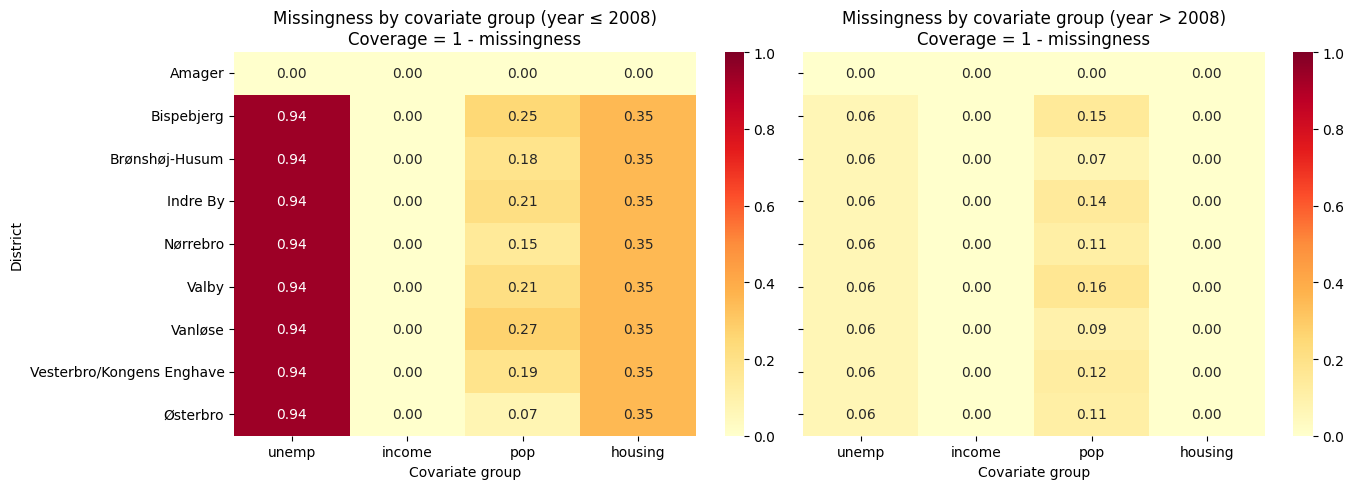

In [22]:
panel = model_panel_full.copy() if "model_panel_full" in globals() else model_panel.copy()

prefixes = ['unemp_', 'income_', 'pop_', 'housing_']
covariate_cols = [c for c in panel.columns if any(c.startswith(p) for p in prefixes)]

def missing_by_group(df_period):
    miss_frac = df_period.groupby('district')[covariate_cols].apply(lambda g: g.isnull().mean())
    out = {}
    for pfx in prefixes:
        cols = [c for c in covariate_cols if c.startswith(pfx)]
        if cols:
            out[pfx.rstrip('_')] = miss_frac[cols].mean(axis=1)
    return pd.DataFrame(out).sort_index()

miss_pre  = missing_by_group(panel[panel['year'] <= 2008])
miss_post = missing_by_group(panel[panel['year'] > 2008])

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

sns.heatmap(miss_pre, annot=True, fmt='.2f', cmap='YlOrRd', vmin=0, vmax=1, ax=axes[0])
axes[0].set_title('Missingness by covariate group (year ≤ 2008)\nCoverage = 1 - missingness')
axes[0].set_xlabel('Covariate group')
axes[0].set_ylabel('District')

sns.heatmap(miss_post, annot=True, fmt='.2f', cmap='YlOrRd', vmin=0, vmax=1, ax=axes[1])
axes[1].set_title('Missingness by covariate group (year > 2008)\nCoverage = 1 - missingness')
axes[1].set_xlabel('Covariate group')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

AI comments: 
- `unemp` row **fully red** before 2008 and white after
- `pop`, `income`, `housing` rows should be **white** (no missing values) for all years after ~1992, confirming those covariates are complete in the restricted panel.
- If any district shows unexpected missing values in `pop` or `income`, investigate whether that district was added to Statistics Denmark's reporting later.

**After this cell, `model_panel_restricted` is ready for Phase 2.4 (covariate reduction).**
The ~200 wide columns will be collapsed to 5–8 interpretable features:
total population, share of non-Danish origin, median disposable income per capita,
unemployment rate, and average household size.


Comments

- test if features are actually indpendent from each other for the Pyro PGM

### 2.4 Reduce covariates to 5-8 summary features
**Why is this necessary?** 

Curse of Dimensionality & Multicollinearity: Currently have around 200 columns (e.g., population counts broken down by every 10-year age bracket and gender. We reduce the ~200 wide columns into 5-8 meaningful, standardized summary features to ensure our Pyro model remains interpretable and computationally stable.

**Design choices**

| Feature | Derivation / Source | Design Rationale & Logic |
| :--- | :--- | :--- |
| **`total_pop`** | Sum of all `pop_*` columns (KKBEF2) | Acts as the base for **per-capita normalization**, ensuring the model captures district intensity rather than just population size. |
| **`share_non_danish`** | (Sum of non-Danish `pop_*` columns) / `total_pop` | **Rate transformation** that captures demographic composition as a latent indicator of district attractiveness and market segmentation. |
| **`log_income_per_capita`** | (Sum of income / `total_pop`), then take natural log | **Normalization** removes size bias; **Log transformation** linearizes the multiplicative price relationship and handles the right-skewness of income data. |
| **`unemployment_rate`** | (Sum of `unemp_*` columns) / working-age population | **Rate transformation** used to capture local economic distress, providing a clearer signal than raw counts of unemployed individuals. |
| **`avg_household_size`** | Weighted average of housing size counts / total households | Distinguishes between **"student/single"** areas and **"family"** areas, which helps the model identify different housing demand profiles. |
| **`year_std`** | Standardized linear time covariate: `(year - mean) / std` | Controls for **general market trends** (inflation/global demand) in a way that is numerically stable and compatible with future forecasting. |
| **Standardization (Z-score)** | Applied to all final features using `StandardScaler` | Crucial for **Prior Alignment**; it allows for a consistent prior (e.g., $Normal(0, 0.5)$) regardless of the original units of the feature. |

**Rationale for Income Transformation (Log Income per Capita)**

To prepare the income data for the Bayesian model, we apply a two-step transformation: **Normalization** and **Logging**. This design is based on the following theoretical foundations:

* **Normalization (Per Capita):** Raw income data (e.g., `income_disposable_amount`) represents district-wide totals. Without dividing by `total_pop`, larger districts would appear artificially "wealthier" simply due to population volume rather than individual prosperity.
* **Linearizing the Relationship (Log):** Economic relationships between income and housing are typically multiplicative rather than additive. People generally allocate a *percentage* of their income to housing; taking the log transforms this multiplicative effect into a linear one ($log(Price) \propto \beta \cdot log(Income)$), aligning with the linear structure of the Pyro observation model.
* **Handling Skewness:** Income distributions are characteristically right-skewed, with high-earning outliers pulling the mean upward. The log transformation compresses these extreme values, creating a more Gaussian (symmetric) distribution. This is critical for the model's **Normal likelihood** ($y_{dt} \sim Normal(\mu_{dt}, \sigma)$), which assumes symmetric residuals.

In [23]:
# Feature engineering: create summary covariates for each group (population, unemployment, income, housing)

panel = pd.read_csv('data/cleaned/model_panel_restricted.csv')

pop_cols = [c for c in panel.columns if c.startswith('pop_')]
unemp_cols = [c for c in panel.columns if c.startswith('unemp_')]
income_cols = [c for c in panel.columns if c.startswith('income_')]
housing_cols = [c for c in panel.columns if c.startswith('housing_')]

# Total population 
# (sum of all ancestry-agegroup columns)
panel['total_population'] = panel[pop_cols].sum(axis=1)

# Share of non-Danish (i.e. foreign) population
#  we identify these as all columns that do NOT contain 'persons_of_danish_origin' in their name
non_danish_pop_cols = [c for c in pop_cols if 'persons_of_danish_origin' not in c]
panel['share_non_danish'] = panel[non_danish_pop_cols].sum(axis=1) / panel['total_population']

# Log income per capita
# sum of all income columns as a proxy for total income, then divide by total population
disp_inc_cols = [c for c in income_cols if 'disposable_income' in c and 'amount_of_income_dkk' in c]
panel['income_per_capita'] = panel[disp_inc_cols].sum(axis=1) * 1000 / panel['total_population']
panel['log_income_per_capita'] = np.log(panel['income_per_capita'])


# Unemployment rate (FTE-weighted)
# KKLEDIG6 breaks unemployed persons by education × degree-of-unemployment bucket
# 'highest_education_completed_total' is the across-education total — using any other education rows would double-count. Each bucket value is a headcount of people who spent that fraction of the year unemployed, so we weight by bucket midpoint to get full-year-equivalent unemployed / working-age-pop (~4-7%, matching Danish reality)
working_age_cols = [c for c in pop_cols if any(g in c for g in ['20_29', '30_39', '40_49', '50_59'])]
panel['working_age_pop'] = panel[working_age_cols].sum(axis=1)

total_edu_unemp_cols = [c for c in unemp_cols if 'highest_education_completed_total' in c]
degree_weights = {'[0_02]': 0.1, ']02_04]': 0.3, ']04_06]': 0.5, ']06_08]': 0.7, ']08_1]': 0.9}
weighted_unemp = pd.Series(0.0, index=panel.index)
for col in total_edu_unemp_cols:
    for slug, w in degree_weights.items():
        if slug in col:
            weighted_unemp += panel[col] * w
panel['unemployment_rate'] = weighted_unemp / panel['working_age_pop']

# Average household size
# KKHUS1 breaks household counts by size × children × type, so we calculate a weighted average household size using the household_size column in the column names
size_map = [('1_person', 1), ('2_persons', 2), ('3_persons', 3), ('4_persons', 4), ('5_persons', 5)]
total_households = pd.Series(0.0, index=panel.index)
weighted_size = pd.Series(0.0, index=panel.index)
for slug, val in size_map:
    size_sum = panel[[c for c in housing_cols if c.startswith(f'housing_{slug}')]].sum(axis=1)
    total_households += size_sum
    weighted_size += val * size_sum
panel['avg_household_size'] = weighted_size / total_households

# Standardised time
panel['year_std'] = (panel['year'] - panel['year'].mean()) / panel['year'].std()

FEATURE_COLS = ['total_population', 'share_non_danish', 'log_income_per_capita',
                'unemployment_rate', 'avg_household_size', 'year_std']

panel.replace([np.inf, -np.inf], np.nan, inplace=True)
panel.dropna(subset=FEATURE_COLS, inplace=True)

# Standardise all features (z-score) for Pyro
scaler = StandardScaler()
X_scaled = scaler.fit_transform(panel[FEATURE_COLS])
for i, c in enumerate(FEATURE_COLS):
    panel[f'{c}_std'] = X_scaled[:, i]

panel.to_csv('data/cleaned/model_panel_features.csv', index=False)
print(panel[FEATURE_COLS].describe())
print("\nMissing values:\n", panel[FEATURE_COLS].isna().sum())
print(f"\nunemployment_rate range: {panel['unemployment_rate'].min():.3f} – {panel['unemployment_rate'].max():.3f}")

       total_population  share_non_danish  log_income_per_capita  \
count        145.000000        145.000000             145.000000   
mean       64966.951724          0.234928              12.853296   
std        26052.955518          0.062774               0.192455   
min        35388.000000          0.106901              12.444191   
25%        46355.000000          0.189586              12.707192   
50%        55689.000000          0.221106              12.835099   
75%        76463.000000          0.268407              12.977015   
max       151049.000000          0.371270              13.379325   

       unemployment_rate  avg_household_size    year_std  
count         145.000000          145.000000  145.000000  
mean            0.047498            1.772876   -0.089801  
std             0.013888            0.100071    0.948818  
min             0.000000            1.546990   -1.627648  
25%             0.037535            1.708925   -0.813824  
50%             0.045804         

### 2.5 Feature EDA
Visualizing correlations and outliers to confirm independence and reliability of our features before PGM construction.

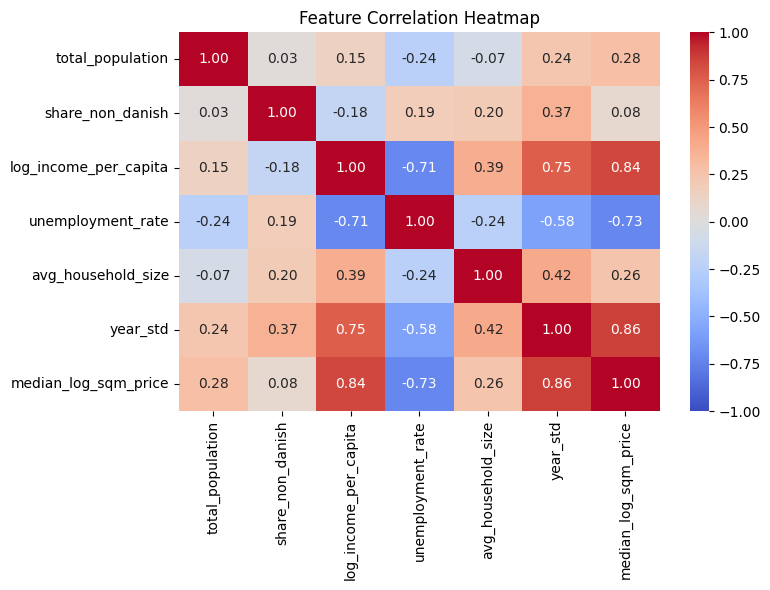

/var/folders/2w/hnlzx3jn2652kr04m9mgwt540000gp/T/ipykernel_31107/3200867831.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/var/folders/2w/hnlzx3jn2652kr04m9mgwt540000gp/T/ipykernel_31107/3200867831.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/var/folders/2w/hnlzx3jn2652kr04m9mgwt540000gp/T/ipykernel_31107/3200867831.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/var/folders/2w/hnlzx3jn2652kr04m9mgwt540000gp/T/ipykernel_31107/3200867831.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, 

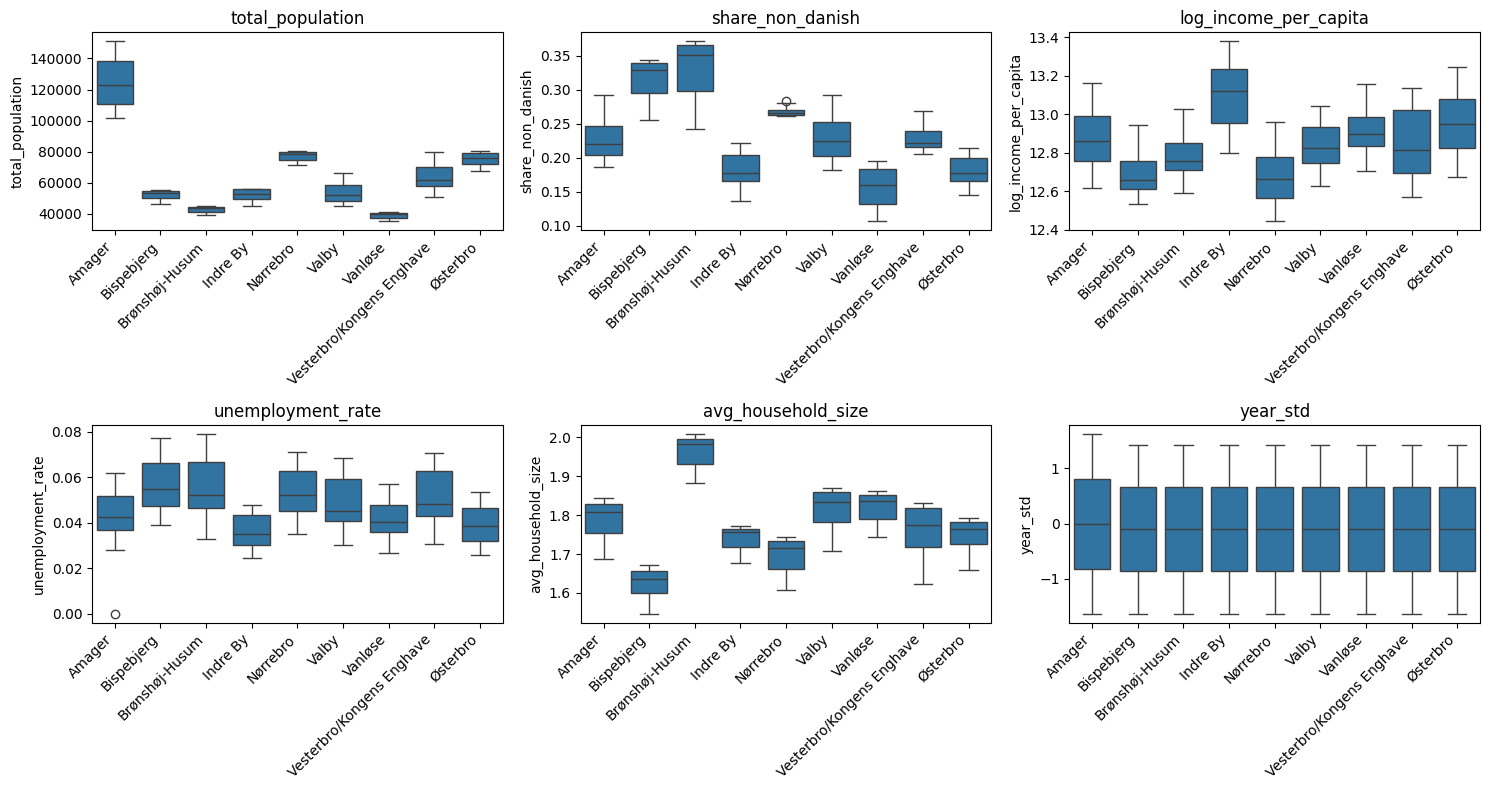

In [24]:
# 1. Correlation Heatmap
corr_cols = FEATURE_COLS + ['median_log_sqm_price']
corr_matrix = panel[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# 2. Outlier Check (Boxplots)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flatten(), FEATURE_COLS):
    sns.boxplot(x='district', y=feat, data=panel, ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_title(feat)
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

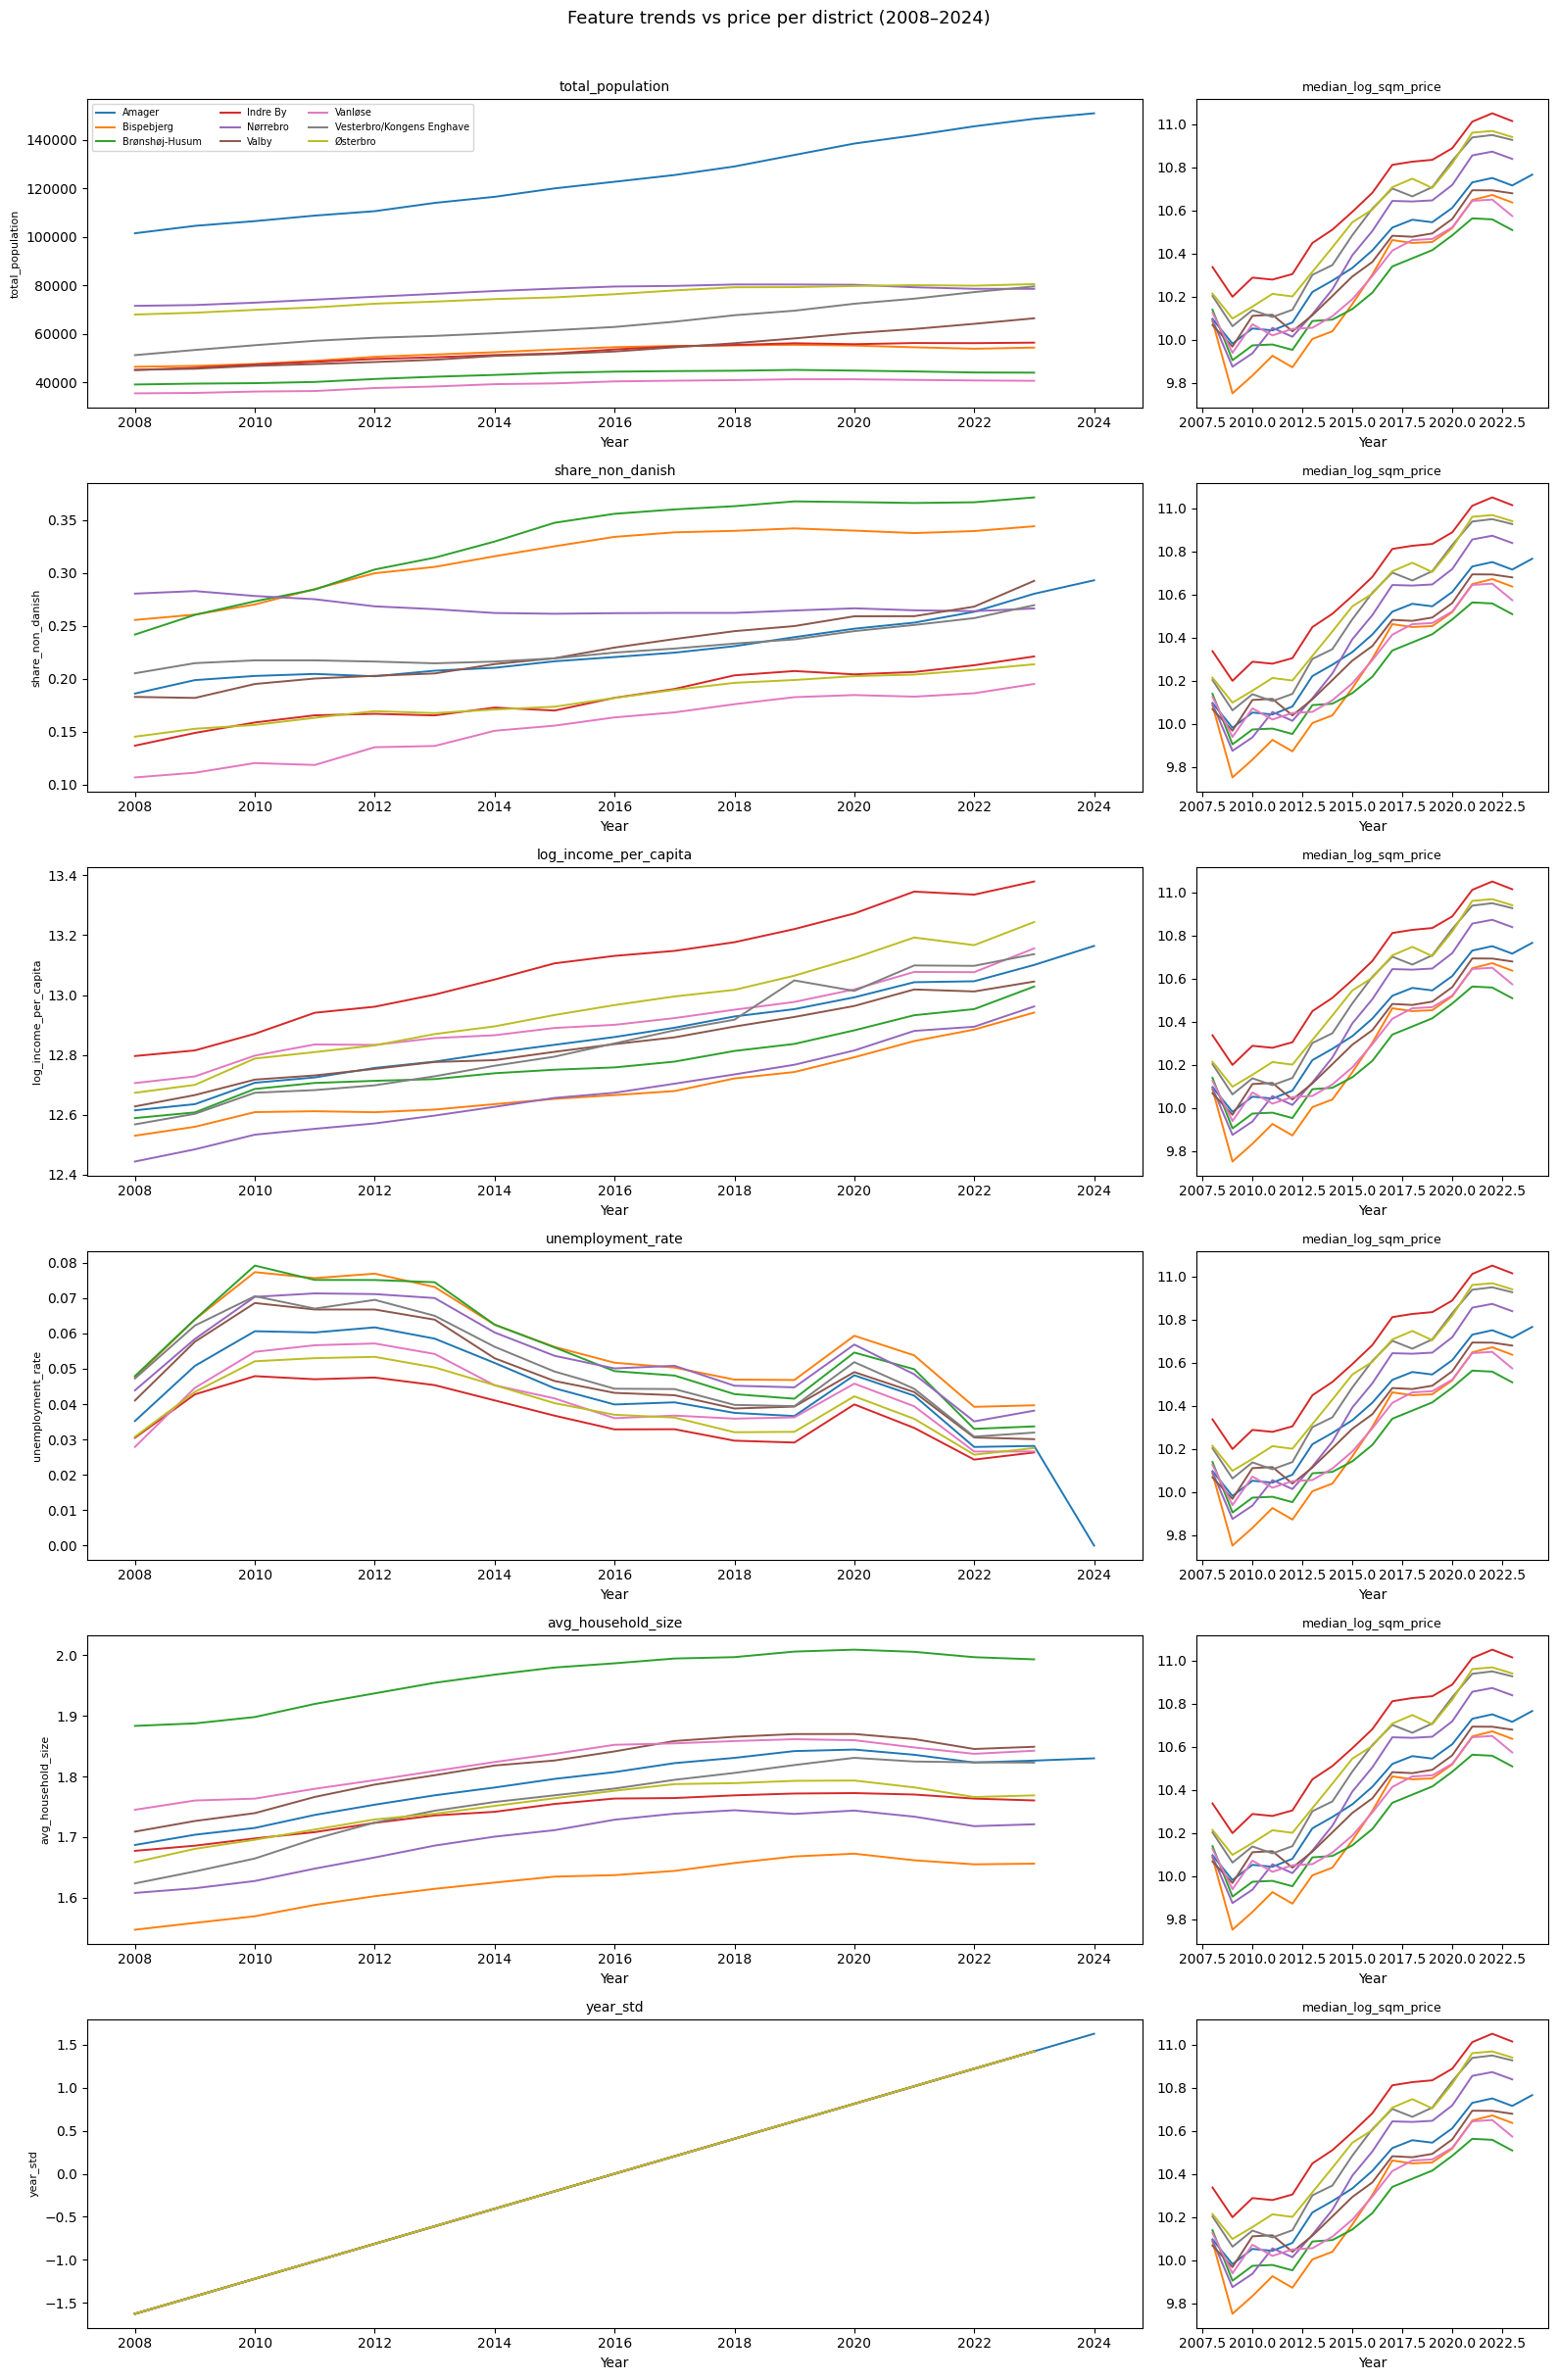

In [25]:
# 3. Feature vs price over time per district
# Left column: feature trend per district. Right column: price for the same districts.
# Lets you visually judge which features co-move with prices and which lead/lag.

districts = sorted(panel['district'].unique())
colors = plt.cm.tab10.colors

fig, axes = plt.subplots(len(FEATURE_COLS), 2, figsize=(16, 4 * len(FEATURE_COLS)),
                         gridspec_kw={'width_ratios': [3, 1]})

for row, feat in enumerate(FEATURE_COLS):
    ax_feat = axes[row, 0]
    ax_price = axes[row, 1]

    for i, dist in enumerate(districts):
        sub = panel[panel['district'] == dist].sort_values('year')
        ax_feat.plot(sub['year'], sub[feat], label=dist, color=colors[i % 10], linewidth=1.4)
        ax_price.plot(sub['year'], sub['median_log_sqm_price'], color=colors[i % 10], linewidth=1.4)

    ax_feat.set_title(feat, fontsize=10)
    ax_feat.set_ylabel(feat, fontsize=8)
    ax_feat.set_xlabel('Year')
    ax_price.set_title('median_log_sqm_price', fontsize=9)
    ax_price.set_xlabel('Year')

    if row == 0:
        ax_feat.legend(fontsize=7, ncol=3, loc='upper left')

plt.suptitle('Feature trends vs price per district (2008–2024)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


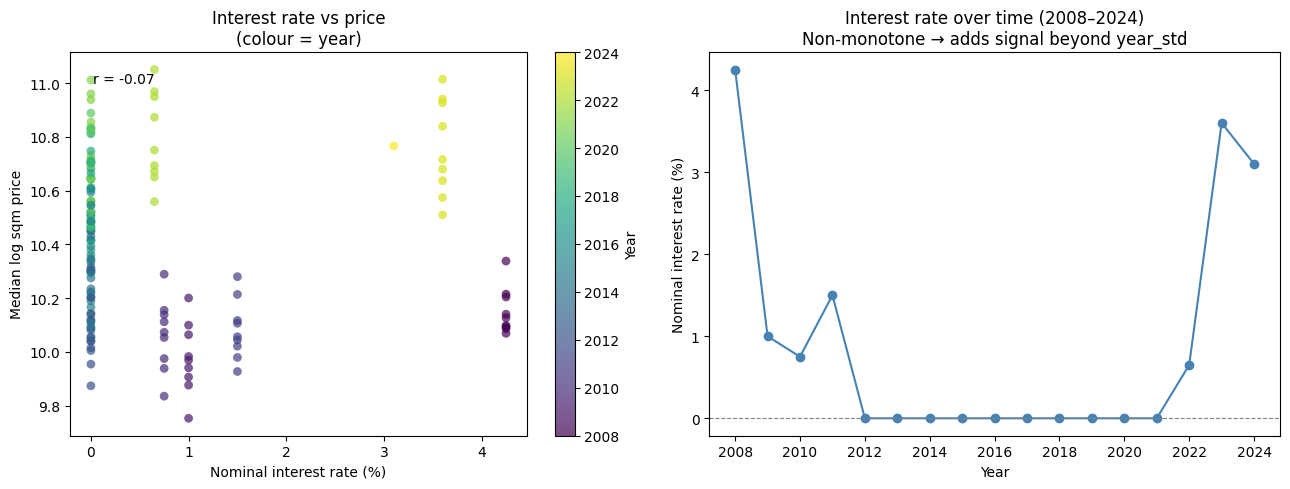

Interest rate range (2008–2024): 0.0 – 4.25 %
Pearson r(interest rate, log sqm price): -0.075


In [26]:
# 4. Macro variable check — nominal interest rate vs median log sqm price
# The interest rate is a national yearly figure recorded on each transaction in df.
# We extract one value per year then merge into the panel by year.
# Expected: negative correlation (higher rates → lower prices).
# Key question: does interest rate merely proxy for time, or add signal beyond year_std?

interest_by_year = (
    df.groupby(df['date'].dt.year)['nom_interest_rate%']
    .first()
    .dropna()
    .reset_index()
    .rename(columns={'date': 'year', 'nom_interest_rate%': 'nom_interest_rate'})
)

panel_with_rate = panel.merge(interest_by_year, on='year', how='left')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: scatter interest rate vs price (all district-years pooled)
ax = axes[0]
sc = ax.scatter(
    panel_with_rate['nom_interest_rate'],
    panel_with_rate['median_log_sqm_price'],
    c=panel_with_rate['year'], cmap='viridis', alpha=0.7, edgecolors='none', s=40
)
plt.colorbar(sc, ax=ax, label='Year')
ax.set_xlabel('Nominal interest rate (%)')
ax.set_ylabel('Median log sqm price')
ax.set_title('Interest rate vs price\n(colour = year)')

# Pearson r annotation
r = panel_with_rate[['nom_interest_rate', 'median_log_sqm_price']].corr().iloc[0, 1]
ax.annotate(f'r = {r:.2f}', xy=(0.05, 0.92), xycoords='axes fraction', fontsize=10)

# Right: interest rate over time (to show it is not just a monotone time proxy)
ax2 = axes[1]
yr_rate = interest_by_year[interest_by_year['year'].between(2008, 2024)]
ax2.plot(yr_rate['year'], yr_rate['nom_interest_rate'], marker='o', color='steelblue')
ax2.set_xlabel('Year')
ax2.set_ylabel('Nominal interest rate (%)')
ax2.set_title('Interest rate over time (2008–2024)\nNon-monotone → adds signal beyond year_std')
ax2.axhline(0, color='grey', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

print("Interest rate range (2008–2024):",
      yr_rate['nom_interest_rate'].min(), "–", yr_rate['nom_interest_rate'].max(), "%")
print("Pearson r(interest rate, log sqm price):", round(r, 3))


**analysis of independence of the features**

Feature independence check
Rows used: 145
Features used: 6

Features:
['total_population', 'share_non_danish', 'log_income_per_capita', 'unemployment_rate', 'avg_household_size', 'year_std']


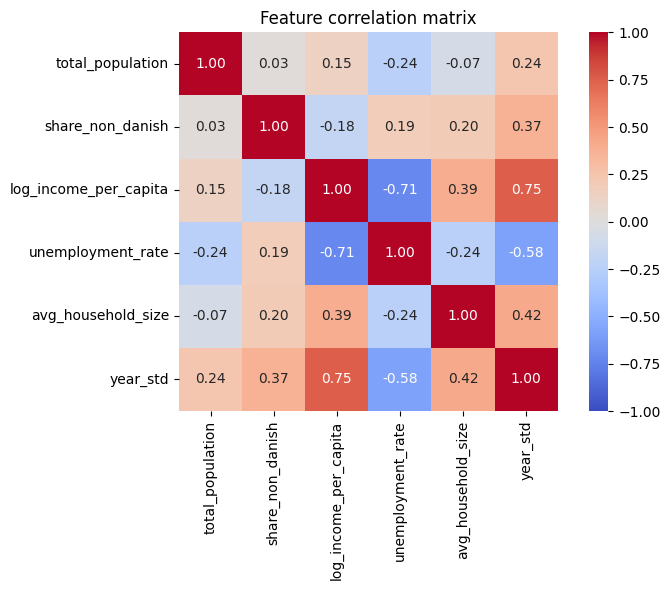


Strongest feature correlations:


,feature_1,feature_2,abs_correlation
11,log_income_per_capita,year_std,0.752764
9,log_income_per_capita,unemployment_rate,0.714610
13,unemployment_rate,year_std,0.582077
14,avg_household_size,year_std,0.416529
10,log_income_per_capita,avg_household_size,0.393655
8,share_non_danish,year_std,0.374950
12,unemployment_rate,avg_household_size,0.238601
4,total_population,year_std,0.237714
2,total_population,unemployment_rate,0.235189
7,share_non_danish,avg_household_size,0.198242



Feature pairs with |correlation| >= 0.7:


,feature_1,feature_2,abs_correlation
11,log_income_per_capita,year_std,0.752764
9,log_income_per_capita,unemployment_rate,0.714610



Variance Inflation Factor (VIF):


,feature,VIF
5,year_std,6.755872
2,log_income_per_capita,6.077454
1,share_non_danish,3.055137
3,unemployment_rate,2.259500
4,avg_household_size,1.332266
0,total_population,1.137991


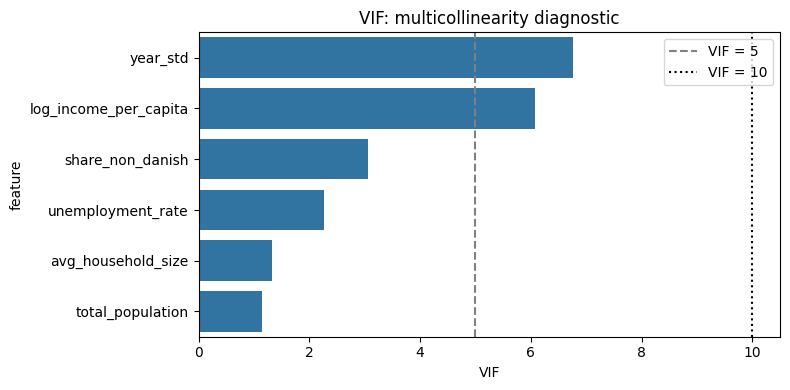


Condition number: 6.01
Interpretation: Low multicollinearity risk.

PCA explained variance:


,PC,explained_variance_ratio,cumulative_variance
0,PC1,0.443785,0.443785
1,PC2,0.219764,0.663549
2,PC3,0.174098,0.837646
3,PC4,0.099269,0.936915
4,PC5,0.050800,0.987715
5,PC6,0.012285,1.000000


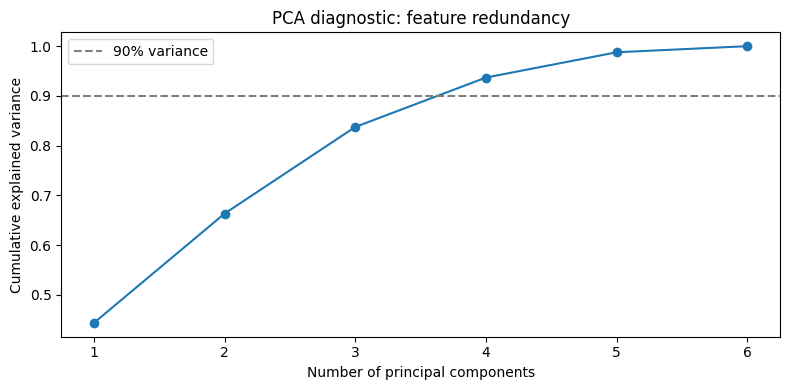


FEATURE INDEPENDENCE / MULTICOLLINEARITY SUMMARY
Maximum absolute pairwise correlation: 0.75
Maximum VIF: 6.76
Condition number: 6.01

Conclusion:
Some dependence between engineered features may be present.
Inspect the high-correlation pairs and VIF values above.
Consider removing, combining, or rethinking highly redundant features.


In [27]:
# -------------------------------------------------------------------
# 5. Feature independence / multicollinearity analysis
# -------------------------------------------------------------------
# Goal:
# Check whether the engineered features are too dependent/correlated.
# This matters because highly dependent features can make beta estimates
# unstable and harder to interpret in the Pyro PGM.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Use the engineered feature columns from Phase 2.4
X_feat = panel[FEATURE_COLS].copy()

# Drop rows with missing values for this diagnostic
X_feat = X_feat.dropna()

print("Feature independence check")
print("Rows used:", X_feat.shape[0])
print("Features used:", X_feat.shape[1])
print("\nFeatures:")
print(FEATURE_COLS)

# -------------------------------------------------------------------
# A) Correlation matrix
# -------------------------------------------------------------------

corr = X_feat.corr(method="pearson")

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True
)
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.show()

# Flag strong pairwise correlations
corr_pairs = (
    corr.abs()
    .where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

corr_pairs.columns = ["feature_1", "feature_2", "abs_correlation"]
corr_pairs = corr_pairs.sort_values("abs_correlation", ascending=False)

print("\nStrongest feature correlations:")
display(corr_pairs.head(10))

high_corr_threshold = 0.70
high_corr_pairs = corr_pairs[corr_pairs["abs_correlation"] >= high_corr_threshold]

if high_corr_pairs.empty:
    print(f"\nNo feature pairs have |correlation| >= {high_corr_threshold}.")
else:
    print(f"\nFeature pairs with |correlation| >= {high_corr_threshold}:")
    display(high_corr_pairs)

# -------------------------------------------------------------------
# B) Variance Inflation Factor (VIF)
# -------------------------------------------------------------------
# VIF measures how much one feature can be explained by the others.
# Rule of thumb:
# VIF < 5  : usually acceptable
# VIF 5-10 : moderate multicollinearity
# VIF > 10 : serious multicollinearity

X_scaled = pd.DataFrame(
    StandardScaler().fit_transform(X_feat),
    columns=X_feat.columns,
    index=X_feat.index
)

vif_df = pd.DataFrame({
    "feature": X_scaled.columns,
    "VIF": [
        variance_inflation_factor(X_scaled.values, i)
        for i in range(X_scaled.shape[1])
    ]
}).sort_values("VIF", ascending=False)

print("\nVariance Inflation Factor (VIF):")
display(vif_df)

plt.figure(figsize=(8, 4))
sns.barplot(data=vif_df, x="VIF", y="feature")
plt.axvline(5, linestyle="--", color="grey", label="VIF = 5")
plt.axvline(10, linestyle=":", color="black", label="VIF = 10")
plt.title("VIF: multicollinearity diagnostic")
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# C) Condition number
# -------------------------------------------------------------------
# Large condition number means the design matrix is close to singular.
# Rule of thumb:
# < 30   : usually fine
# 30-100 : possible multicollinearity
# > 100  : strong multicollinearity

condition_number = np.linalg.cond(X_scaled.values)

print(f"\nCondition number: {condition_number:.2f}")

if condition_number < 30:
    print("Interpretation: Low multicollinearity risk.")
elif condition_number < 100:
    print("Interpretation: Moderate multicollinearity risk.")
else:
    print("Interpretation: High multicollinearity risk.")

# -------------------------------------------------------------------
# D) PCA diagnostic
# -------------------------------------------------------------------
# If very few principal components explain almost all variance,
# features may contain overlapping information.

pca = PCA()
pca.fit(X_scaled)

pca_summary = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(FEATURE_COLS))],
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_variance": np.cumsum(pca.explained_variance_ratio_)
})

print("\nPCA explained variance:")
display(pca_summary)

plt.figure(figsize=(8, 4))
plt.plot(
    range(1, len(FEATURE_COLS) + 1),
    pca_summary["cumulative_variance"],
    marker="o"
)
plt.axhline(0.90, linestyle="--", color="grey", label="90% variance")
plt.xticks(range(1, len(FEATURE_COLS) + 1))
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA diagnostic: feature redundancy")
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# E) Final automatic summary
# -------------------------------------------------------------------

print("\n" + "="*70)
print("FEATURE INDEPENDENCE / MULTICOLLINEARITY SUMMARY")
print("="*70)

max_corr = corr_pairs["abs_correlation"].max()
max_vif = vif_df["VIF"].max()

print(f"Maximum absolute pairwise correlation: {max_corr:.2f}")
print(f"Maximum VIF: {max_vif:.2f}")
print(f"Condition number: {condition_number:.2f}")

if max_corr < 0.70 and max_vif < 5 and condition_number < 30:
    print("\nConclusion:")
    print("The engineered features appear reasonably independent for the Pyro model.")
    print("No serious multicollinearity issues detected.")
else:
    print("\nConclusion:")
    print("Some dependence between engineered features may be present.")
    print("Inspect the high-correlation pairs and VIF values above.")
    print("Consider removing, combining, or rethinking highly redundant features.")

## Phase 4 - Pyro Implementation


In [28]:
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import Adam
import torch
from sklearn.linear_model import LinearRegression
from pyro.infer.autoguide import AutoNormal
from pyro.infer.autoguide import AutoDiagonalNormal, AutoMultivariateNormal
from sklearn.model_selection import train_test_split
from pyro.infer import MCMC, NUTS, HMC, SVI, Trace_ELBO
from pyro.optim import Adam, ClippedAdam
from pyro.infer import Predictive

# Save all column names to a text file
with open('data/cleaned/panel_columns.txt', 'w') as f:
    for i, col in enumerate(panel.columns, 1):
        f.write(f"{i:3d}. {col}\n")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Phase 4.1 - Bayesian Linear Regression

In [29]:
# Establish the reference point (start of the data)
start_date = df['date'].min()

# Calculate months since start
df['months_since_start'] = (
    (df['date'].dt.year - start_date.year) * 12 + 
    (df['date'].dt.month - start_date.month)
)

df['quarters_since_start'] = (
    (df['date'].dt.year - start_date.year) * 4 + 
    (df['date'].dt.quarter - start_date.quarter)
)

df['purchase_since_build'] = df['date'].dt.year - df['year_build']

X_housing_type = pd.get_dummies(df['house_type'], prefix='housing_type')
X_sale_type = pd.get_dummies(df['sales_type'], prefix='sales_type')
X_neighborhood = pd.get_dummies(df['neighborhood'], prefix='neighborhood')

X = pd.concat([df[['quarters_since_start', 'purchase_since_build', 'no_rooms', 'sqm']], X_housing_type, X_neighborhood], axis=1)


X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X = (X - X_mean) / X_std

y = df['purchase_price'].values
y_mean = y.mean()
y_std = y.std()
y = (y - y_mean) / y_std

print(X.shape)
print(y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print("X train: %d rows, %d cols" % X_train.shape)
print("X test: %d rows, %d cols" % X_test.shape)

(150382, 19)
(150382,)
X train: 105267 rows, 19 cols
X test: 45115 rows, 19 cols


In [30]:
feature_cols = list(X_train.columns)
def model(X, obs=None):
    alpha = pyro.sample("alpha", dist.Normal(0., 1.))                   # Prior for the bias/intercept
    feature_names = list(X_train.columns)
    betas_list = list()
    for i, name in enumerate(feature_names):
        betas_list.append( pyro.sample(f"beta_{name}", dist.Normal(0., 1.)))
    sigma = pyro.sample("sigma", dist.HalfCauchy(5.))                   # Prior for the variance
    betas = torch.stack(betas_list)
    
    with pyro.plate("data"):
        y = pyro.sample("y", dist.Normal(alpha + X.matmul(betas), sigma), obs=obs)
        
    return y

In [31]:
# Prepare data for Pyro model
X_train_torch = torch.tensor(X_train.values).float()
y_train_torch = torch.tensor(y_train).float()

# Define guide function
guide = AutoMultivariateNormal(model)

# Reset parameter values
pyro.clear_param_store()
# Define the number of optimization steps
n_steps = 8000

# Setup the optimizer
adam_params = {"lr": 0.001} # learning rate (lr) of optimizer
optimizer = ClippedAdam(adam_params)

# Setup the inference algorithm
elbo = Trace_ELBO(num_particles=1)
svi = SVI(model, guide, optimizer, loss=elbo)
# Do gradient steps
for step in range(n_steps):
    elbo = svi.step(X_train_torch, y_train_torch)
    if step % 100 == 0:
        print("[%d] ELBO: %.1f" % (step, elbo))
        


# Get the list of all sites starting with 'beta_'
beta_site_names = [f"beta_{name}" for name in X_train.columns]
all_sites = ("alpha", "sigma") + tuple(beta_site_names)

predictive = Predictive(model, guide=guide, num_samples=1000,
                        return_sites=all_sites)

samples = predictive(X_train_torch, y_train_torch)

# Extract alpha
alpha_samples = samples["alpha"].squeeze().detach().numpy() # [1000]

# Reconstruct the beta matrix [1000, num_features]
# We stack all individual beta_samples back into one array
beta_samples = np.stack([samples[site].squeeze().detach().numpy() for site in beta_site_names], axis=1)


[0] ELBO: 319526.2
[100] ELBO: 289429.3
[200] ELBO: 295886.2
[300] ELBO: 256270.8
[400] ELBO: 272041.4
[500] ELBO: 236700.2
[600] ELBO: 233431.0
[700] ELBO: 213348.3
[800] ELBO: 236601.8
[900] ELBO: 219024.3
[1000] ELBO: 197386.5
[1100] ELBO: 173300.8
[1200] ELBO: 168953.8
[1300] ELBO: 164198.9
[1400] ELBO: 164063.5
[1500] ELBO: 160753.3
[1600] ELBO: 135690.3
[1700] ELBO: 123898.9
[1800] ELBO: 133688.3
[1900] ELBO: 124779.4
[2000] ELBO: 121205.5
[2100] ELBO: 115980.3
[2200] ELBO: 110994.7
[2300] ELBO: 116086.1
[2400] ELBO: 110908.0
[2500] ELBO: 111012.3
[2600] ELBO: 111004.0
[2700] ELBO: 112182.8
[2800] ELBO: 110486.7
[2900] ELBO: 111515.6
[3000] ELBO: 111089.6
[3100] ELBO: 110145.7
[3200] ELBO: 110558.8
[3300] ELBO: 109950.0
[3400] ELBO: 110202.3
[3500] ELBO: 110256.1
[3600] ELBO: 110033.0
[3700] ELBO: 110039.9
[3800] ELBO: 110068.9
[3900] ELBO: 110307.8
[4000] ELBO: 109961.8
[4100] ELBO: 109786.4
[4200] ELBO: 109800.2
[4300] ELBO: 109913.1
[4400] ELBO: 109892.4
[4500] ELBO: 109779.9


In [32]:
def compute_error(trues, predicted):
    corr = np.corrcoef(predicted, trues)[0,1]
    mae = np.mean(np.abs(predicted - trues))
    rae = np.sum(np.abs(predicted - trues)) / np.sum(np.abs(trues - np.mean(trues)))
    rmse = np.sqrt(np.mean((predicted - trues)**2))
    r2 = max(0, 1 - np.sum((trues-predicted)**2) / np.sum((trues - np.mean(trues))**2))
    return corr, mae, rae, rmse, r2

y_hat_samples = alpha_samples + np.dot(X_test, beta_samples.T)
y_hat = np.mean(y_hat_samples, axis=1)

preds = y_hat * y_std + y_mean
y_true = y_test * y_std + y_mean
corr, mae, rae, rmse, r2 = compute_error(y_true, preds)
print("CorrCoef: %.3f\nMAE: %.3f\nRMSE: %.3f\nR2: %.3f" % (corr, mae, rmse, r2))

CorrCoef: 0.738
MAE: 945521.157
RMSE: 1374761.147
R2: 0.545


In [33]:
for name in beta_site_names:
    print(f"{name}: mean={samples[name].mean():.3f}, std={samples[name].std():.3f}" )

beta_quarters_since_start: mean=0.478, std=0.002
beta_purchase_since_build: mean=-0.018, std=0.003
beta_no_rooms: mean=0.163, std=0.008
beta_sqm: mean=0.418, std=0.007
beta_housing_type_Apartment: mean=0.230, std=0.015
beta_housing_type_Farm: mean=0.018, std=0.002
beta_housing_type_Summerhouse: mean=0.026, std=0.003
beta_housing_type_Townhouse: mean=0.183, std=0.010
beta_housing_type_Villa: mean=0.206, std=0.013
beta_neighborhood_Amager: mean=0.211, std=0.004
beta_neighborhood_Bispebjerg: mean=0.064, std=0.003
beta_neighborhood_Brønshøj-Husum: mean=0.078, std=0.002
beta_neighborhood_Frederiksberg: mean=0.254, std=0.004
beta_neighborhood_Indre By: mean=0.232, std=0.004
beta_neighborhood_Nørrebro: mean=0.121, std=0.003
beta_neighborhood_Valby: mean=0.110, std=0.003
beta_neighborhood_Vanløse: mean=0.087, std=0.003
beta_neighborhood_Vesterbro: mean=0.221, std=0.004
beta_neighborhood_Østerbro: mean=0.248, std=0.004


Time series AR model

In [34]:
housing_agg.columns

Index(['district', 'year', 'median_log_sqm_price', 'mean_log_sqm_price',
       'std_log_sqm_price', 'n_transactions', 'median_sqm',
       'median_purchase_price', 'pct_change_median'],
      dtype='object')

In [35]:
model_panel.columns

Index(['district', 'year', 'median_log_sqm_price', 'mean_log_sqm_price',
       'std_log_sqm_price', 'n_transactions', 'median_sqm',
       'median_purchase_price', 'pct_change_median',
       'pop_descendants_of_non_western_origin_0_10_years_men',
       ...
       'housing_5_persons_1_child_single_men',
       'housing_5_persons_1_child_single_women',
       'housing_5_persons_2_children_couples_living_in_consensual_union_and_cohabiting_couples',
       'housing_5_persons_2_children_married_couples_and_registered_partnership',
       'housing_5_persons_2_children_single_men',
       'housing_5_persons_2_children_single_women',
       'housing_5_persons_3_children_couples_living_in_consensual_union_and_cohabiting_couples',
       'housing_5_persons_3_children_married_couples_and_registered_partnership',
       'housing_5_persons_3_children_single_men',
       'housing_5_persons_3_children_single_women'],
      dtype='object', length=219)

### ARIMA(1,1,0) time-series model on district-year prices

We now model a **single district’s** time series of **`median_log_sqm_price`** with an **ARIMA(1,1,0)** model (difference once, then AR(1) on differences).

$$
g_{t,i} = y_{t,i} - y_{t-1, i}
$$
$$
g_{t,i} \sim \mathcal{N}(\mu_{g, i} + \phi(g_{t-1,i}-\mu_g),\ \sigma_{g,i})\,,\qquad \phi\in(-1,1)
$$
$$
i\in\{{\text{Amager, Bispebjerg, Brønshøj-Husum, Indre By, Nørrebro, Valby, Vanløse, Vesterbro, Østerbro}}\}
$$

- **Why log?** Housing prices are positive and typically right-skewed; using `log(sqm_price)` makes the distribution closer to Gaussian and turns multiplicative effects into additive ones, matching the Normal likelihood assumption.
- **Why median?** Robust to outliers/luxury transactions.

Below we do a **train/test split** (hold out last years), fit on train only, then **forecast the test horizon** with **posterior predictive intervals** and plot **truth vs forecast**.

**Note:** ARIMA(1,1,0) *does* use $\Delta y_t$, but in the code below we feed the model the **level series `y`** (price values) and compute $\Delta y_t$ **inside the model** — so you can keep interpreting forecasts on the **level** scale (`median_log_sqm_price`).

## Just for district: Indre By, AR(1) model:

In [39]:
import numpy as np
import pandas as pd
import torch

# ------------------------------------------------------------
# 1) Select data: one district time series (district x year panel)
# ------------------------------------------------------------
if "model_panel_restricted" in globals():
    panel_df = model_panel_restricted
elif "model_panel" in globals():
    panel_df = model_panel
else:
    panel_df = pd.read_csv("data/cleaned/model_panel_restricted.csv")

# Pick one district (univariate time series)
district = "Indre By"  # <- change me

ts = (
    panel_df.loc[panel_df["district"] == district, ["year", "median_log_sqm_price"]]
    .dropna()
    .sort_values("year")
    .reset_index(drop=True)
)

# To make AR(1) directly comparable with ARX (feature panel ends at 2023),
# we stop the AR(1) series at 2023 as well.
ts = ts[ts["year"] <= 2023].reset_index(drop=True)

years = ts["year"].to_numpy()
y = torch.tensor(ts["median_log_sqm_price"].to_numpy(), dtype=torch.float)  # LEVEL series (interpretable)

# ------------------------------------------------------------
# 2) (Optional) Standardize for inference stability.
#    We still forecast/plot in original y units by back-transforming.
# ------------------------------------------------------------
y_mean = y.mean()
y_std = y.std()
y_std = y_std if y_std > 0 else torch.tensor(1.0)
y_z = (y - y_mean) / y_std

# ------------------------------------------------------------
# 3) Train/test split on the LEVEL series
# ------------------------------------------------------------
T = len(y_z)
N_TEST = 5  # <- change me
T_train = max(5, T - N_TEST)  # need >= 3 points; keep a little buffer for ARIMA

years_train, years_test = years[:T_train], years[T_train:]
y_train_z, y_test_z = y_z[:T_train], y_z[T_train:]

def _info():
    print(f"District: {district}")
    print(f"Total length: {T} years ({years.min()}–{years.max()})")
    print(f"Train: {len(y_train_z)} years ({years_train.min()}–{years_train.max()})")
    if len(years_test):
        print(f"Test:  {len(y_test_z)} years ({years_test.min()}–{years_test.max()})")
    else:
        print("Test: 0 years (increase N_TEST or ensure longer series)")

_info()

# 4) Difference + mean-center (TRAIN ONLY)
if len(y_train_z) < 3:
    raise ValueError("Need at least 3 training points.")

g_train = y_train_z[1:] - y_train_z[:-1]   # length T_train-1
g_mean = g_train.mean()                    # scalar
g_train_c = g_train - g_mean               # centered diffs
g0_c = g_train_c[-1]                       # last centered diff

h = len(y_test_z)                          # forecast horizon in LEVELS
print("Train mean diff (z-space):", float(g_mean))

District: Indre By
Total length: 16 years (2008–2023)
Train: 11 years (2008–2018)
Test:  5 years (2019–2023)
Train mean diff (z-space): 0.16492430865764618


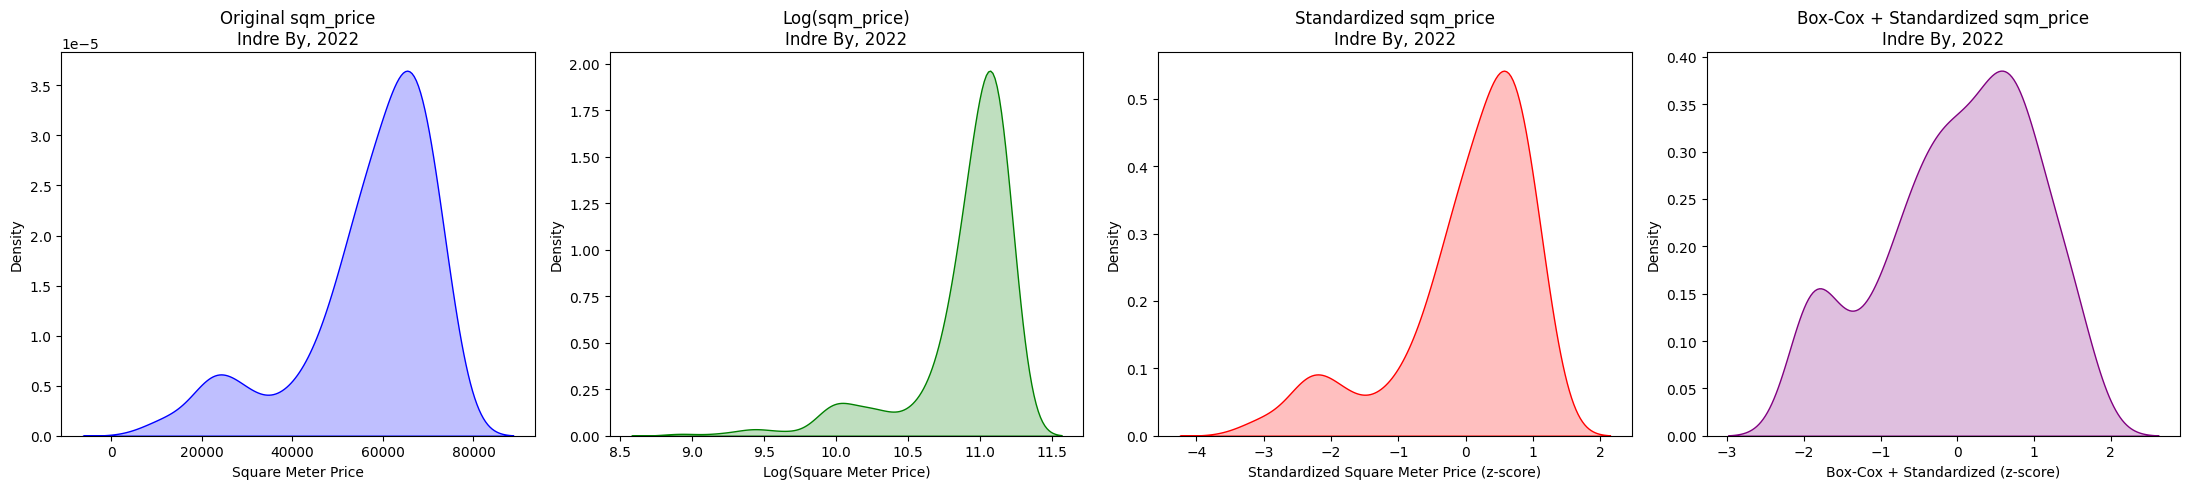

In [72]:
import seaborn as sns
from scipy.stats import zscore, boxcox

test_year = 2022
test_neighborhood = "Indre By"

df_test = df[(df['date'].dt.year == test_year) & (df['neighborhood'] == test_neighborhood)]

# Ensure 'sqm_price' is numeric and drop NaN values
sqm_prices = df_test['sqm_price'].dropna()
log_sqm_prices = np.log(sqm_prices)

# Standardize the original data
std_sqm_prices = zscore(sqm_prices)

# Apply Box-Cox transformation (requires positive data)
boxcox_sqm_prices, _ = boxcox(sqm_prices + 1)  # +1 to avoid log(0) if any zero values exist
std_boxcox_sqm_prices = zscore(boxcox_sqm_prices)

# Create a figure with four subplots
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(22, 5))

# --- Plot 1: Original sqm_price ---
sns.kdeplot(x=sqm_prices, ax=ax1, fill=True, color='blue')
ax1.set_title(f'Original sqm_price\n{test_neighborhood}, {test_year}')
ax1.set_xlabel('Square Meter Price')
ax1.set_ylabel('Density')

# --- Plot 2: Log-transformed sqm_price ---
sns.kdeplot(x=log_sqm_prices, ax=ax2, fill=True, color='green')
ax2.set_title(f'Log(sqm_price)\n{test_neighborhood}, {test_year}')
ax2.set_xlabel('Log(Square Meter Price)')
ax2.set_ylabel('Density')

# --- Plot 3: Standardized sqm_price ---
sns.kdeplot(x=std_sqm_prices, ax=ax3, fill=True, color='red')
ax3.set_title(f'Standardized sqm_price\n{test_neighborhood}, {test_year}')
ax3.set_xlabel('Standardized Square Meter Price (z-score)')
ax3.set_ylabel('Density')

# --- Plot 4: Box-Cox-transformed and standardized sqm_price ---
sns.kdeplot(x=std_boxcox_sqm_prices, ax=ax4, fill=True, color='purple')
ax4.set_title(f'Box-Cox + Standardized sqm_price\n{test_neighborhood}, {test_year}')
ax4.set_xlabel('Box-Cox + Standardized (z-score)')
ax4.set_ylabel('Density')

# Adjust layout and show
plt.tight_layout()
plt.show()

In [36]:
import pyro
import pyro.distributions as dist
from pyro.infer import MCMC, NUTS

# ------------------------------------------------------------
# Simple AR(1) on mean-centered differences (TRAIN ONLY)
#
# We already computed in the previous cell:
#   g_train      = Δy_train
#   g_train_c    = g_train - mean(g_train)
#
# Model:
#   g'_t = phi * g'_{t-1} + eps_t
#   eps_t ~ Normal(0, sigma_g)
# ------------------------------------------------------------



#PGM for AR(1) on mean centered and differenced data defined below

def ar1_centered_diff_model(g_c_obs):
    """
    g_c_obs: 1D tensor of centered diffs (length Tdiff)
    """
    T_ = g_c_obs.shape[0]
    if T_ < 2:
        raise ValueError("Need at least 2 diff observations to fit AR(1).")

    # constrain phi to (-1, 1)
    # prior for latent variables defined:
    phi_raw = pyro.sample("phi_raw", dist.Normal(0.0, 0.5))
    phi = pyro.deterministic("phi", torch.tanh(phi_raw))

    sigma_g = pyro.sample("sigma_g", dist.HalfNormal(1.0))

    # likelihood
    # seperate for first observation
    pyro.sample("g0", dist.Normal(0.0, sigma_g), obs=g_c_obs[0])
    mean = phi * g_c_obs[:-1]
    pyro.sample("g1T", dist.Normal(mean, sigma_g).to_event(1), obs=g_c_obs[1:])


def simulate_centered_diffs(phi, sigma_g, g0_c, horizon):
    """
    Simulate future centered diffs g'_{t+1:t+h} given last centered diff g0_c.
    Returns tensor shape [h].
    """
    ys = []
    prev = g0_c
    for _ in range(horizon):
        mean = phi * prev
        prev = dist.Normal(mean, sigma_g).sample()
        ys.append(prev)
    return torch.stack(ys)


In [37]:
import numpy as np
import torch
import pyro
from pyro.infer import MCMC, NUTS

# ------------------------------------------------------------
# Fit AR(1) on centered diffs (TRAIN ONLY)
# ------------------------------------------------------------

pyro.set_rng_seed(0)
pyro.clear_param_store()

nuts = NUTS(ar1_centered_diff_model, target_accept_prob=0.9)
mcmc = MCMC(nuts, num_samples=600, warmup_steps=400, num_chains=1)

mcmc.run(g_train_c)
posterior = mcmc.get_samples()

phi_raw_post = posterior["phi_raw"].detach().cpu().numpy()
phi_post = np.tanh(phi_raw_post)
sig_g_post = posterior["sigma_g"].detach().cpu().numpy()

print("Posterior summary (train fit)")
print("phi mean:", phi_post.mean(), "phi 5/95:", np.quantile(phi_post, [0.05, 0.95]))
print("sigma_g mean:", sig_g_post.mean())

# ------------------------------------------------------------
# NOTE
# We intentionally do NOT reconstruct the level series y_t here.
# The next cell visualizes the modeled series directly: centered diffs g'.
# ------------------------------------------------------------


Sample: 100%|██████████| 1000/1000 [00:03, 311.94it/s, step size=7.61e-01, acc. prob=0.936]

Posterior summary (train fit)
phi mean: -0.08081989 phi 5/95: [-0.62061608  0.42226554]
sigma_g mean: 0.3148653


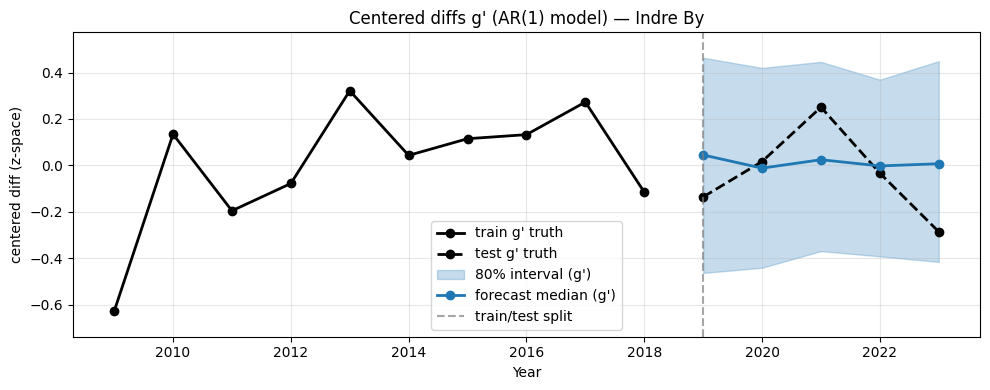

2019 centered-diff error (forecast - truth): +0.1808
2020 centered-diff error (forecast - truth): -0.0285
2021 centered-diff error (forecast - truth): -0.2265
2022 centered-diff error (forecast - truth): +0.0311
2023 centered-diff error (forecast - truth): +0.2933


In [38]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# ------------------------------------------------------------
# Plot the *modeled* series: centered differences g'
#   g_t  = y_t - y_{t-1}
#   g'_t = g_t - mean(g_train)
# ------------------------------------------------------------

# Train centered diffs already computed as g_train_c
years_train_diff = years_train[1:]
g_train_c_np = g_train_c.detach().numpy()

# Build test centered diffs from held-out levels (z-space)
if len(y_test_z) == 0:
    raise ValueError("No test years. Reduce N_TEST or choose a district with more years.")

g_test = torch.empty_like(y_test_z)
# first test diff: from last train level -> first test level
g_test[0] = y_test_z[0] - y_train_z[-1]
if len(y_test_z) > 1:
    g_test[1:] = y_test_z[1:] - y_test_z[:-1]

g_test_c = g_test - g_mean
g_test_c_np = g_test_c.detach().numpy()

# Posterior predictive for centered diffs over test horizon
S = 300
paths_g = []
for s in range(min(S, len(phi_post))):
    phi_s = torch.tensor(phi_post[s], dtype=torch.float)
    sig_s = torch.tensor(sig_g_post[s], dtype=torch.float)
    paths_g.append(simulate_centered_diffs(phi_s, sig_s, g0_c=g0_c, horizon=len(y_test_z)))

paths_g = torch.stack(paths_g)  # [S, h] centered diffs

p10_g = paths_g.quantile(0.10, dim=0).detach().numpy()
p50_g = paths_g.quantile(0.50, dim=0).detach().numpy()
p90_g = paths_g.quantile(0.90, dim=0).detach().numpy()

plt.figure(figsize=(10, 4))

# Keep identical y-scale across AR / ARX and avoid clipping
y_lo = float(min(g_train_c_np.min(), g_test_c_np.min(), p10_g.min()))
y_hi = float(max(g_train_c_np.max(), g_test_c_np.max(), p90_g.max()))
pad = 0.10 * (y_hi - y_lo + 1e-6)
plt.ylim(y_lo - pad, y_hi + pad)

plt.plot(years_train_diff, g_train_c_np, marker="o", color="black", linewidth=2, label="train g' truth")
plt.plot(years_test, g_test_c_np, marker="o", color="black", linestyle="--", linewidth=2, label="test g' truth")

plt.fill_between(years_test, p10_g, p90_g, alpha=0.25, color="C0", label="80% interval (g')")
plt.plot(years_test, p50_g, marker="o", linewidth=2, color="C0", label="forecast median (g')")

plt.axvline(years_test[0], color="grey", linestyle="--", alpha=0.7, label="train/test split")

plt.title(f"Centered diffs g' (AR(1) model) — {district}")
plt.xlabel("Year")
plt.ylabel("centered diff (z-space)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Per-year errors on centered diffs
err_g = p50_g - g_test_c_np
for yr, e in zip(years_test, err_g):
    print(f"{int(yr)} centered-diff error (forecast - truth): {e:+.4f}")

Visualising posterior using KDE, from output of the MCMC simulation

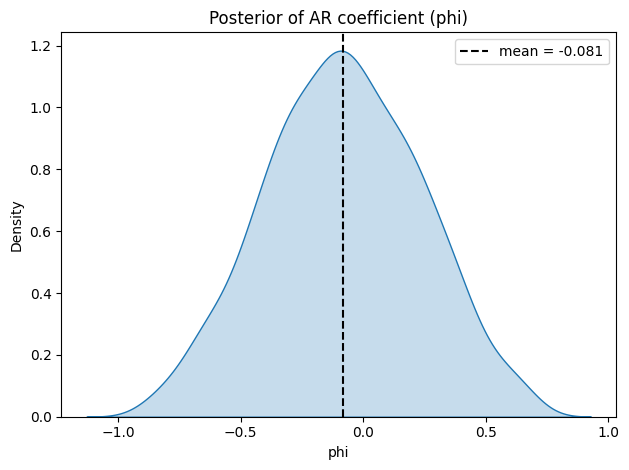

In [39]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

m = float(np.mean(phi_post))
sns.kdeplot(phi_post, fill=True)
plt.axvline(m, color="k", linestyle="--", label=f"mean = {m:.3f}")
plt.title("Posterior of AR coefficient (phi)")
plt.xlabel("phi")
plt.legend()
plt.tight_layout()
plt.show()

## Gaussian Mixture & ARIMA(1,1,0) models on district-year prices

We model each **district's** time series of **`median_log_sqm_price`** from two complementary angles: a **Gaussian Mixture Model (GMM)** that captures the full cross-sectional price distribution within a neighborhood-year cell, and an **ARIMA(1,1,0)** model that captures the temporal dynamics of the median price over time.

$$
i\in\{\text{Amager, Bispebjerg, Brønshøj-Husum, Indre By, Nørrebro, Valby, Vanløse, Vesterbro, Østerbro}\}
$$

---

#### Gaussian Mixture Model — cross-sectional price distribution

Rather than predicting a single point estimate, we model the **full distribution** of transaction prices within each neighborhood-year cell. This allows us to characterize local market heterogeneity and generate probabilistic forecasts.

Housing markets are rarely unimodal — within a single neighborhood, prices may cluster around distinct segments (e.g. smaller apartments vs. larger family homes). A single Gaussian fails to capture this structure; a **two-component GMM** accommodates such bimodality naturally.

For each district $i$ and year $t$, we model the log-price distribution as:

$$
p(\log y \mid i, t) = \pi_{i,t} \cdot \mathcal{N}(\mu_{1,i,t},\ \sigma_{1,i,t}^2) + (1 - \pi_{i,t}) \cdot \mathcal{N}(\mu_{2,i,t},\ \sigma_{2,i,t}^2)
$$

where $\pi_{i,t} \in (0,1)$ is the mixing weight and the two components represent distinct price segments in the local market. The model is fitted per neighborhood-year cell; held-out transactions from year $t$ are scored against the fitted mixture using log-likelihood.

---

#### ARIMA(1,1,0) — temporal dynamics of median price

We model the evolution of `median_log_sqm_price` over time with an **ARIMA(1,1,0)** model: difference once to achieve stationarity, then fit an AR(1) on the differences.

$$
g_{t,i} = y_{t,i} - y_{t-1,i}
$$
$$
g_{t,i} \sim \mathcal{N}\!\left(\mu_{g,i} + \phi\,(g_{t-1,i} - \mu_{g,i}),\ \sigma_{g,i}^2\right), \qquad \phi \in (-1,1)
$$

- **Why log?** Housing prices are positive and right-skewed; `log(sqm_price)` makes the distribution closer to Gaussian and turns multiplicative effects into additive ones, consistent with the Normal likelihood.
- **Why median?** Robust to outliers and luxury transactions.

We perform a **train/test split** (holding out the last years), fit on the training set only, then **forecast the test horizon** with **posterior predictive intervals** and evaluate **truth vs. forecast**.

> **Note:** Although ARIMA(1,1,0) operates on $\Delta y_t$, the model is fed the **level series** `y` and computes differences internally — so forecasts are interpreted directly on the `median_log_sqm_price` scale.

---

Together, the GMM describes *where prices are* at any given point in time, while the ARIMA describes *how the center of that distribution moves* over time.

### First: Implement a basic mixture model

In [ ]:
from torch.distributions import constraints
district = "Indre By"
year = 2022
K = 2


y = df[(df['neighborhood'] == district) & (df['date'].dt.year == year)]['sqm_price'].values

# Standardize the data
y_mean = y.mean()
y_std = y.std()
y_normalized = (y - y_mean) / y_std
y_torch = torch.tensor(y_normalized, dtype=torch.float)


def gmm(data=None, K=2):
    # Prior for the mixing proportions
    weights = pyro.sample("weights", pyro.distributions.Dirichlet(torch.ones(K))) # this is pi who account for the weight of each component in the mixture
    sigma_loc = pyro.param("sigma_loc", torch.ones(K), constraint=constraints.positive)
    # Priors for the mixture components
    with pyro.plate('components', K):
        mu = pyro.sample('mu', pyro.distributions.Normal(torch.zeros(K), 5.*torch.ones(K)))
        sigma = pyro.sample('sigma', pyro.distributions.Gamma(sigma_loc, 1.0))

    with pyro.plate('data', len(data)):
        assignment = pyro.sample('assignment', pyro.distributions.Categorical(weights), infer={"enumerate": "parallel"})
        points = pyro.sample('obs', pyro.distributions.Normal(mu[assignment], sigma[assignment]), obs=data)

    return points


In [173]:


# Run inference in Pyro
nuts_kernel = NUTS(gmm)
mcmc = MCMC(nuts_kernel, num_samples=1000, warmup_steps=500, num_chains=1)
mcmc.run(y_torch)

# Show summary of inference results
mcmc.summary()

Sample: 100%|██████████| 1500/1500 [00:25, 58.99it/s, step size=3.11e-01, acc. prob=0.944]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
     mu[0]     -1.56      0.30     -1.57     -2.07     -1.11    211.64      1.00
     mu[1]      0.41      0.05      0.41      0.33      0.49    240.68      1.00
  sigma[0]      0.90      0.17      0.92      0.62      1.17    210.61      1.00
  sigma[1]      0.49      0.04      0.48      0.42      0.55    221.17      1.00
weights[0]      0.21      0.05      0.21      0.13      0.29    236.54      1.00
weights[1]      0.79      0.05      0.79      0.71      0.87    236.54      1.00

Number of divergences: 0


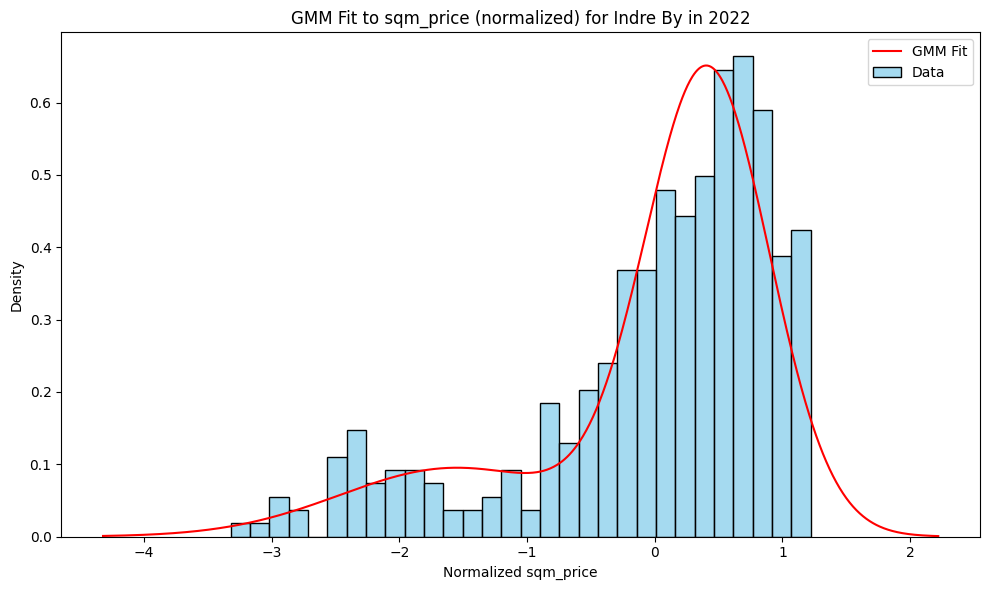

In [178]:
mcmc_samples = mcmc.get_samples()
weights_samples = mcmc_samples['weights'].detach().numpy()
mu_samples = mcmc_samples['mu'].detach().numpy()
sigma_samples = mcmc_samples['sigma'].detach().numpy()

# Plot the results

mu = mu_samples.mean(axis=0)
sigma = sigma_samples.mean(axis=0)

x = np.linspace(y_normalized.min() - 1, y_normalized.max() + 1, 1000)
pdf = np.zeros_like(x)
for k in range(K):
    pdf += weights_samples[:, k].mean() * (1/(sigma[k] * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu[k]) / sigma[k])**2)
    
plt.figure(figsize=(10, 6))
sns.histplot(y_normalized, bins=30, kde=False, stat='density', color='skyblue', label='Data')
plt.plot(x, pdf, color='red', label='GMM Fit')
plt.title(f'GMM Fit to sqm_price (normalized) for {district} in {year}')
plt.xlabel('Normalized sqm_price')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()


## Indre By — ARX(1) model (AR(1) on differences + exogenous features)

We extend the ARIMA(1,1,0) model by adding **exogenous (X) covariates** from the socioeconomic panel.

Let $y_t$ be `median_log_sqm_price` for a single district and $g_t = y_t - y_{t-1}$. Using the same mean-centering as above, we model centered differences $g'_t$ as:

$$
 g'_t = \phi\, g'_{t-1} + \beta^\top x_t + \epsilon_t\,,\qquad \epsilon_t \sim \mathcal{N}(0,\sigma_g)
$$

Here $x_t$ are the standardized feature columns (`*_std`) aligned to year $t$.

District: Indre By
Total length: 16 years (2008–2023)
Train: 11 years (2008–2018)
Test:  5 years (2019–2023)
Train mean diff (z-space): 0.16492430865764618


Sample: 100%|██████████| 1000/1000 [00:42, 23.44it/s, step size=9.26e-02, acc. prob=0.923]



Posterior summary (train fit)
phi mean: -0.4082109034061432 phi 5/95: [-0.74359598  0.0364658 ]
sigma_g mean: 0.19279250502586365
beta means:
  total_population_std: +0.090
  share_non_danish_std: -0.156
  log_income_per_capita_std: +0.306
  unemployment_rate_std: +0.374
  avg_household_size_std: +0.249
  year_std_std: +0.191


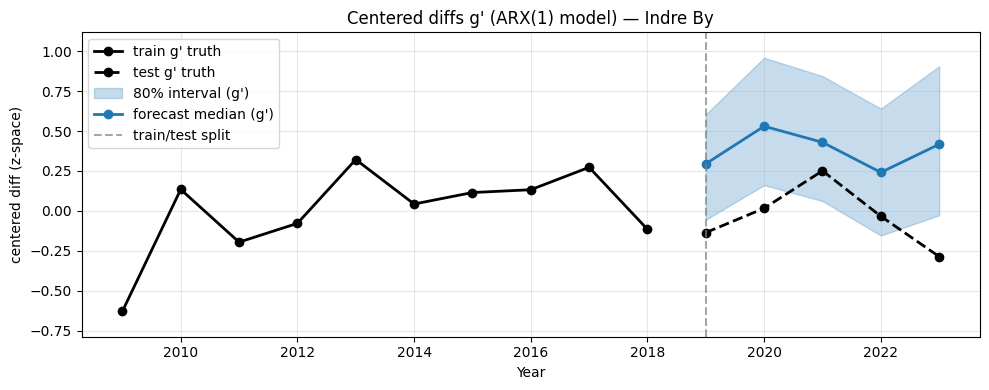

2019 centered-diff error (forecast - truth): +0.4310
2020 centered-diff error (forecast - truth): +0.5137
2021 centered-diff error (forecast - truth): +0.1787
2022 centered-diff error (forecast - truth): +0.2746
2023 centered-diff error (forecast - truth): +0.7034


In [40]:
import numpy as np
import pandas as pd
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import MCMC, NUTS
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1) Load panel with standardized features
# ------------------------------------------------------------
features_df = pd.read_csv("data/cleaned/model_panel_features.csv")

district = "Indre By"  # <- change me
N_TEST = 5

FEATURE_COLS_STD = [
    "total_population_std",
    "share_non_danish_std",
    "log_income_per_capita_std",
    "unemployment_rate_std",
    "avg_household_size_std",
    "year_std_std",
]

ts = (
    features_df.loc[
        features_df["district"] == district,
        ["year", "median_log_sqm_price", *FEATURE_COLS_STD],
    ]
    .dropna()
    .sort_values("year")
    .reset_index(drop=True)
)

years = ts["year"].to_numpy()
y = torch.tensor(ts["median_log_sqm_price"].to_numpy(), dtype=torch.float)
X = torch.tensor(ts[FEATURE_COLS_STD].to_numpy(), dtype=torch.float)

# Standardize y for inference stability (as in ARIMA section)
y_mean = y.mean()
y_std = y.std()
y_std = y_std if y_std > 0 else torch.tensor(1.0)
y_z = (y - y_mean) / y_std

T = len(y_z)
T_train = max(5, T - N_TEST)
h = T - T_train

print(f"District: {district}")
print(f"Total length: {T} years ({years.min()}–{years.max()})")
print(f"Train: {T_train} years ({years[:T_train].min()}–{years[:T_train].max()})")
print(f"Test:  {h} years ({years[T_train:].min()}–{years[T_train:].max()})" if h > 0 else "Test: 0 years")

# ------------------------------------------------------------
# 2) Differences + mean-center (TRAIN ONLY)
# ------------------------------------------------------------
# g_t corresponds to year index t (difference y_t - y_{t-1}), so align X at year t
if T_train < 3:
    raise ValueError("Need at least 3 training points.")

g = y_z[1:] - y_z[:-1]              # length T-1
X_g = X[1:]                          # length T-1, aligned to g

g_train = g[: T_train - 1]
X_g_train = X_g[: T_train - 1]

g_mean = g_train.mean()
g_train_c = g_train - g_mean

g0_c = g_train_c[-1]
y_last = y_z[T_train - 1]

X_g_future = X_g[T_train - 1 : T_train - 1 + h]  # length h

print("Train mean diff (z-space):", float(g_mean))

# ------------------------------------------------------------
# 3) ARX(1) on centered diffs: g'_t = phi g'_{t-1} + beta^T x_t + eps
# ------------------------------------------------------------

def arx1_centered_diff_model(g_c_obs, X_obs):
    """g_c_obs: [Tdiff], X_obs: [Tdiff, K]"""
    Tdiff, K = X_obs.shape
    if Tdiff < 2:
        raise ValueError("Need at least 2 diff observations to fit ARX(1).")


    #phi is alpha, there is one alpha because it is the coefficnt for prev value
    phi_raw = pyro.sample("phi_raw", dist.Normal(0.0, 0.5))
    phi = pyro.deterministic("phi", torch.tanh(phi_raw))

    #beta is beta, there are K betas because there are K features
    beta = pyro.sample("beta", dist.Normal(0.0, 0.5).expand([K]).to_event(1))
    sigma_g = pyro.sample("sigma_g", dist.HalfNormal(1.0))

    # First centered diff
    mean0 = (X_obs[0] * beta).sum()
    pyro.sample("g0", dist.Normal(mean0, sigma_g), obs=g_c_obs[0])

    # Remaining centered diffs
    mean = phi * g_c_obs[:-1] + (X_obs[1:] @ beta)
    pyro.sample("g1T", dist.Normal(mean, sigma_g).to_event(1), obs=g_c_obs[1:])


def simulate_centered_diffs_arx(phi, beta, sigma_g, g0_c, X_future):
    """Simulate future centered diffs given future X. Returns [h]."""
    ys = []
    prev = g0_c
    for t in range(X_future.shape[0]):
        mean = phi * prev + (X_future[t] * beta).sum()
        prev = dist.Normal(mean, sigma_g).sample()
        ys.append(prev)
    return torch.stack(ys) if ys else torch.empty((0,), dtype=torch.float)


# ------------------------------------------------------------
# 4) Fit + posterior predictive forecast
# ------------------------------------------------------------
pyro.set_rng_seed(0)
pyro.clear_param_store()

nuts = NUTS(arx1_centered_diff_model, target_accept_prob=0.9)
mcmc = MCMC(nuts, num_samples=600, warmup_steps=400, num_chains=1)

mcmc.run(g_train_c, X_g_train)
posterior = mcmc.get_samples()

phi_post = np.tanh(posterior["phi_raw"].detach().cpu().numpy())
beta_post = posterior["beta"].detach().cpu().numpy()  # [S, K]
sig_g_post = posterior["sigma_g"].detach().cpu().numpy()

print("\nPosterior summary (train fit)")
print("phi mean:", float(phi_post.mean()), "phi 5/95:", np.quantile(phi_post, [0.05, 0.95]))
print("sigma_g mean:", float(sig_g_post.mean()))
print("beta means:")
for name, m in zip(FEATURE_COLS_STD, beta_post.mean(axis=0)):
    print(f"  {name}: {m:+.3f}")

if h == 0:
    raise ValueError("No test years. Reduce N_TEST or ensure longer series.")

# ------------------------------------------------------------
# Posterior predictive on the modeled series: centered diffs g'
#   g_t  = y_t - y_{t-1}
#   g'_t = g_t - mean(g_train)
# ------------------------------------------------------------

years_train_diff = years[:T_train][1:]
years_test = years[T_train:]

g_train_c_np = g_train_c.detach().numpy()

# Build test centered diffs from held-out levels (z-space)
if h == 0:
    raise ValueError("No test years. Reduce N_TEST or ensure longer series.")

g_test = torch.empty((h,), dtype=torch.float)
# first test diff: from last train level -> first test level
g_test[0] = y_z[T_train] - y_z[T_train - 1]
if h > 1:
    g_test[1:] = y_z[T_train + 1 : T_train + h] - y_z[T_train : T_train + h - 1]

g_test_c = g_test - g_mean
g_test_c_np = g_test_c.detach().numpy()

# Posterior predictive for centered diffs over test horizon
S = min(300, len(phi_post))
paths_g = []
for s in range(S):
    phi_s = torch.tensor(phi_post[s], dtype=torch.float)
    beta_s = torch.tensor(beta_post[s], dtype=torch.float)
    sig_s = torch.tensor(sig_g_post[s], dtype=torch.float)
    paths_g.append(simulate_centered_diffs_arx(phi_s, beta_s, sig_s, g0_c=g0_c, X_future=X_g_future))

paths_g = torch.stack(paths_g)  # [S, h] centered diffs

p10_g = paths_g.quantile(0.10, dim=0).detach().numpy()
p50_g = paths_g.quantile(0.50, dim=0).detach().numpy()
p90_g = paths_g.quantile(0.90, dim=0).detach().numpy()

plt.figure(figsize=(10, 4))

# Keep identical y-scale across AR / ARX and avoid clipping
y_lo = float(min(g_train_c_np.min(), g_test_c_np.min(), p10_g.min()))
y_hi = float(max(g_train_c_np.max(), g_test_c_np.max(), p90_g.max()))
pad = 0.10 * (y_hi - y_lo + 1e-6)
plt.ylim(y_lo - pad, y_hi + pad)

plt.plot(years_train_diff, g_train_c_np, marker="o", color="black", linewidth=2, label="train g' truth")
plt.plot(years_test, g_test_c_np, marker="o", color="black", linestyle="--", linewidth=2, label="test g' truth")

plt.fill_between(years_test, p10_g, p90_g, alpha=0.25, color="C0", label="80% interval (g')")
plt.plot(years_test, p50_g, marker="o", linewidth=2, color="C0", label="forecast median (g')")

plt.axvline(years_test[0], color="grey", linestyle="--", alpha=0.7, label="train/test split")
plt.title(f"Centered diffs g' (ARX(1) model) — {district}")
plt.xlabel("Year")
plt.ylabel("centered diff (z-space)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Per-year errors on centered diffs
err_g = p50_g - g_test_c_np
for yr, e in zip(years_test, err_g):
    print(f"{int(yr)} centered-diff error (forecast - truth): {e:+.4f}")

## Hierarchical ARX(1) across all districts (district-level \(\phi_d\), \(\beta_d\)) — test 2019–2023

We now fit one model to **all districts** jointly, with **partial pooling**:

- District-specific AR coefficient: \(\phi_d\)
- District-specific feature weights: \(\beta_d \in \mathbb{R}^K\)
- (Optionally shared) innovation scale: \(\sigma_g\)

The observation is the **centered differenced series** \(g'_{d,t}\) (computed per district using the **train mean**), with exogenous features \(x_{d,t}\) (standardized feature columns).

Train uses years **2008–2018** and test uses **2019–2023** (so plotted test diffs are years 2019–2023).

Districts: 9
Years: 2008–2023 (T=16)
Diff years: 2009–2023 (Tdiff=15)
Train years (levels): 2008–2018
Test years  (levels): 2019–2023
Test years  (diffs):  2019–2023


Sample: 100%|██████████| 800/800 [09:11,  1.45it/s, step size=1.09e-02, acc. prob=0.990]


Posterior (hierarchical) summary
mu_phi mean: -0.5070796012878418
sigma_g mean: 0.22336959838867188


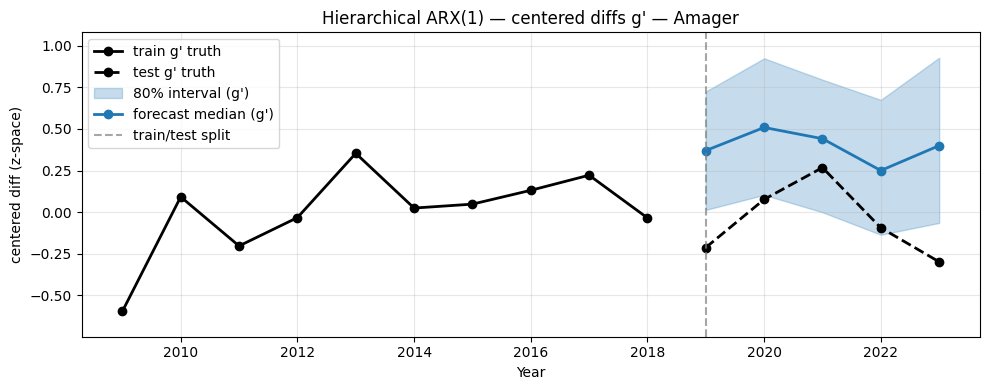

Amager 2019 centered-diff error (forecast - truth): +0.5833
Amager 2020 centered-diff error (forecast - truth): +0.4327
Amager 2021 centered-diff error (forecast - truth): +0.1739
Amager 2022 centered-diff error (forecast - truth): +0.3446
Amager 2023 centered-diff error (forecast - truth): +0.6990


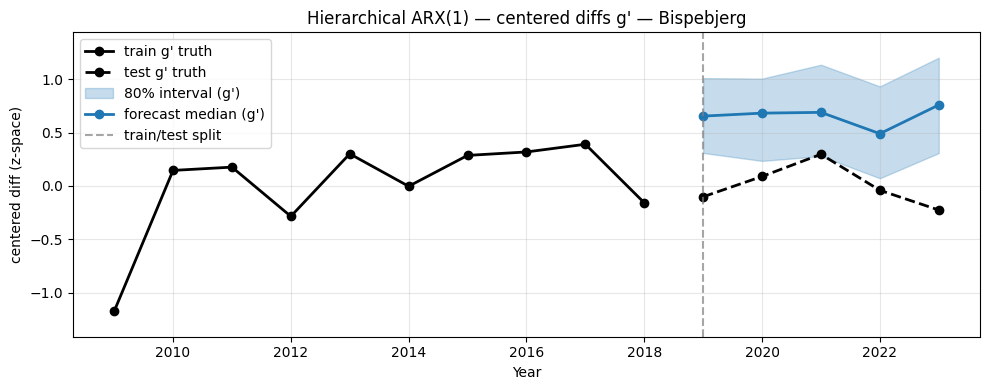

Bispebjerg 2019 centered-diff error (forecast - truth): +0.7557
Bispebjerg 2020 centered-diff error (forecast - truth): +0.5929
Bispebjerg 2021 centered-diff error (forecast - truth): +0.3927
Bispebjerg 2022 centered-diff error (forecast - truth): +0.5304
Bispebjerg 2023 centered-diff error (forecast - truth): +0.9841


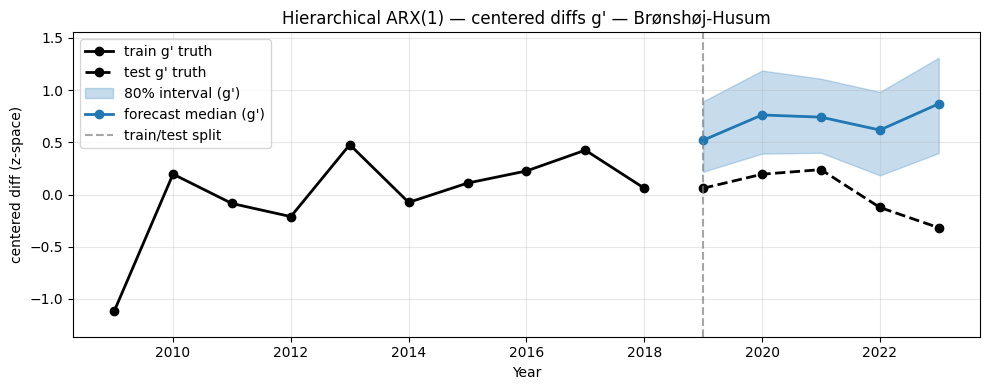

Brønshøj-Husum 2019 centered-diff error (forecast - truth): +0.4601
Brønshøj-Husum 2020 centered-diff error (forecast - truth): +0.5679
Brønshøj-Husum 2021 centered-diff error (forecast - truth): +0.5029
Brønshøj-Husum 2022 centered-diff error (forecast - truth): +0.7417
Brønshøj-Husum 2023 centered-diff error (forecast - truth): +1.1878


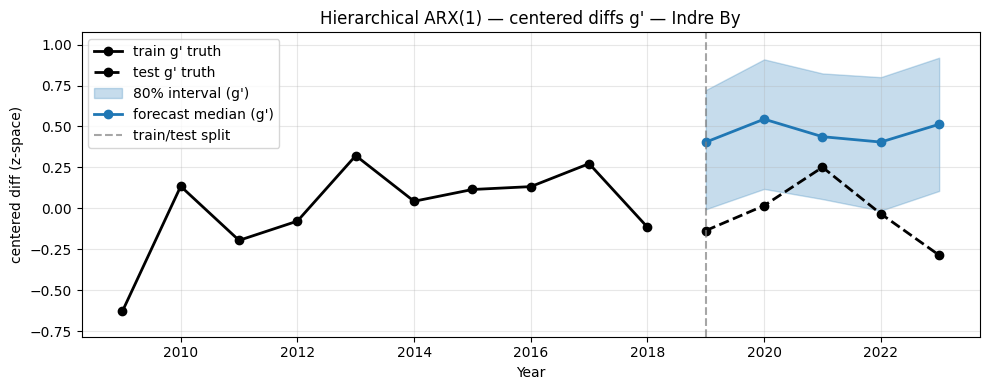

Indre By 2019 centered-diff error (forecast - truth): +0.5402
Indre By 2020 centered-diff error (forecast - truth): +0.5281
Indre By 2021 centered-diff error (forecast - truth): +0.1866
Indre By 2022 centered-diff error (forecast - truth): +0.4383
Indre By 2023 centered-diff error (forecast - truth): +0.7995


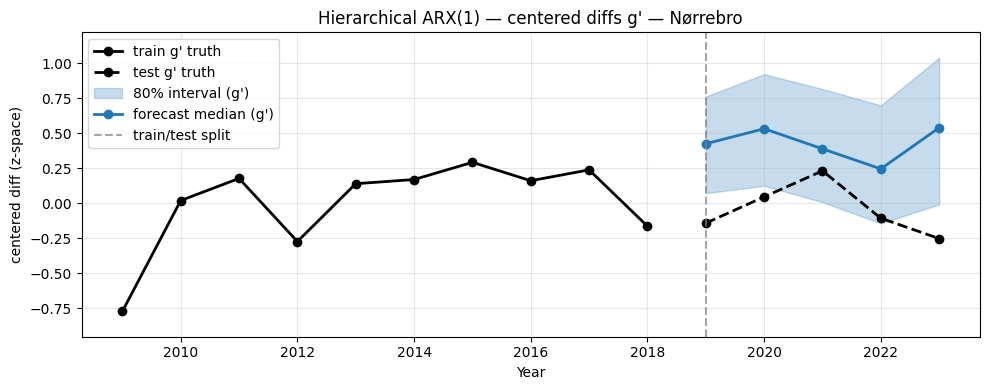

Nørrebro 2019 centered-diff error (forecast - truth): +0.5667
Nørrebro 2020 centered-diff error (forecast - truth): +0.4864
Nørrebro 2021 centered-diff error (forecast - truth): +0.1573
Nørrebro 2022 centered-diff error (forecast - truth): +0.3522
Nørrebro 2023 centered-diff error (forecast - truth): +0.7913


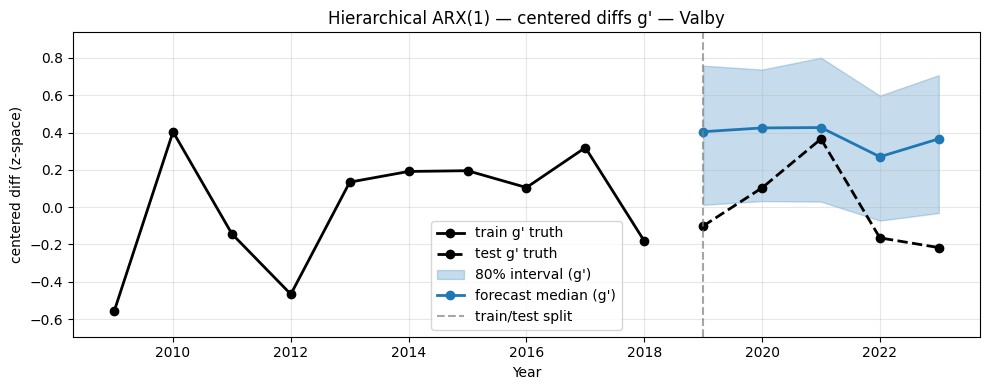

Valby 2019 centered-diff error (forecast - truth): +0.5056
Valby 2020 centered-diff error (forecast - truth): +0.3211
Valby 2021 centered-diff error (forecast - truth): +0.0611
Valby 2022 centered-diff error (forecast - truth): +0.4348
Valby 2023 centered-diff error (forecast - truth): +0.5829


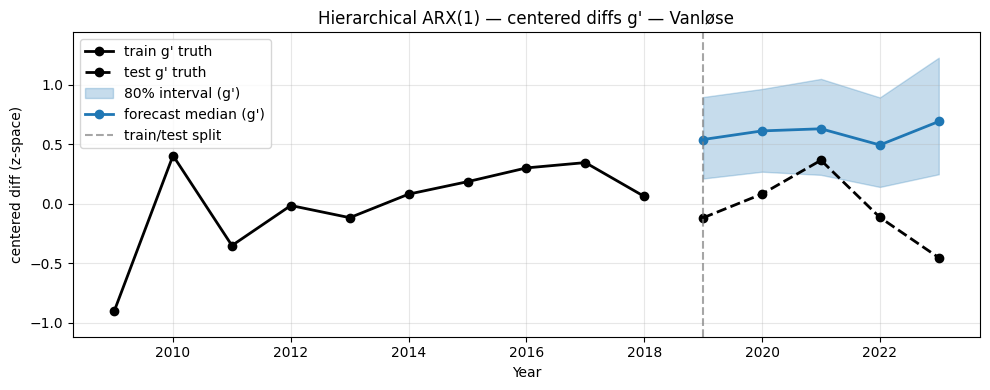

Vanløse 2019 centered-diff error (forecast - truth): +0.6570
Vanløse 2020 centered-diff error (forecast - truth): +0.5298
Vanløse 2021 centered-diff error (forecast - truth): +0.2642
Vanløse 2022 centered-diff error (forecast - truth): +0.6081
Vanløse 2023 centered-diff error (forecast - truth): +1.1434


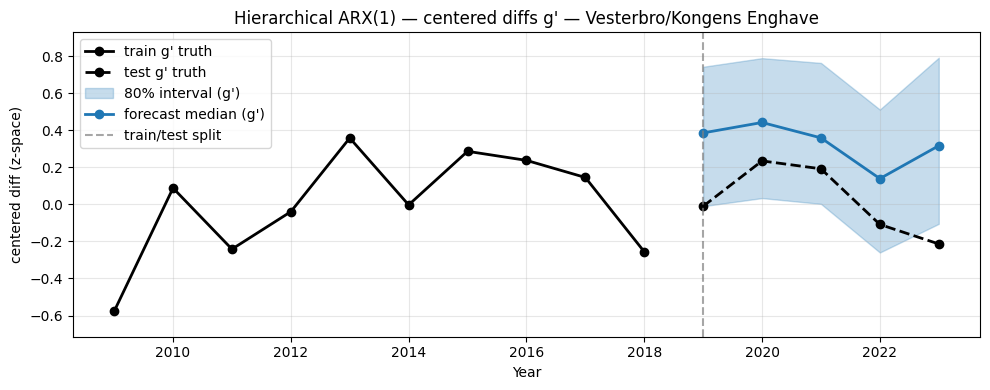

Vesterbro/Kongens Enghave 2019 centered-diff error (forecast - truth): +0.3961
Vesterbro/Kongens Enghave 2020 centered-diff error (forecast - truth): +0.2075
Vesterbro/Kongens Enghave 2021 centered-diff error (forecast - truth): +0.1670
Vesterbro/Kongens Enghave 2022 centered-diff error (forecast - truth): +0.2475
Vesterbro/Kongens Enghave 2023 centered-diff error (forecast - truth): +0.5304


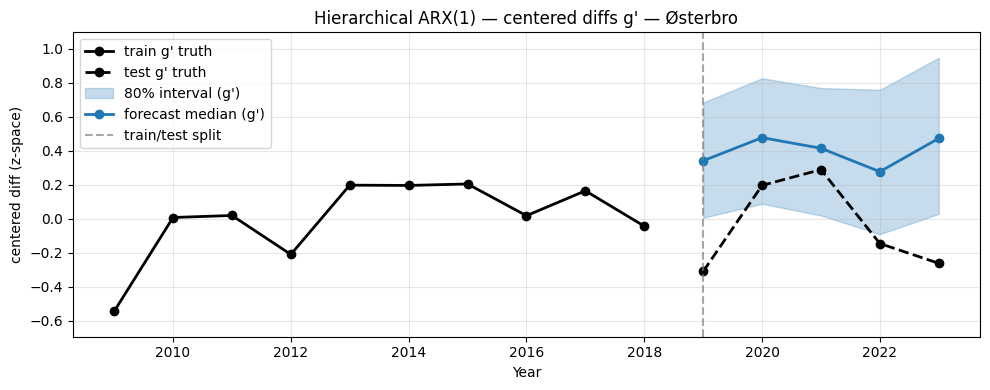

Østerbro 2019 centered-diff error (forecast - truth): +0.6515
Østerbro 2020 centered-diff error (forecast - truth): +0.2807
Østerbro 2021 centered-diff error (forecast - truth): +0.1258
Østerbro 2022 centered-diff error (forecast - truth): +0.4228
Østerbro 2023 centered-diff error (forecast - truth): +0.7352


In [41]:
import numpy as np
import pandas as pd
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import MCMC, NUTS
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1) Load feature panel (ends at 2023) and build a balanced district×year panel
# ------------------------------------------------------------
features_df = pd.read_csv("data/cleaned/model_panel_features.csv")

FEATURE_COLS_STD = [
    "total_population_std",
    "share_non_danish_std",
    "log_income_per_capita_std",
    "unemployment_rate_std",
    "avg_household_size_std",
    "year_std_std",
]

# years (model_panel_features is already restricted; Indre By ends at 2023)
years_all = np.sort(features_df["year"].unique())
# keep 2008–2023 explicitly
years_all = years_all[(years_all >= 2008) & (years_all <= 2023)]

districts = sorted(features_df["district"].unique())
D = len(districts)
K = len(FEATURE_COLS_STD)

# pivot into tensors [D, T]
T = len(years_all)

def _district_block(d):
    df_d = (
        features_df.loc[
            features_df["district"] == d,
            ["year", "median_log_sqm_price", *FEATURE_COLS_STD],
        ]
        .dropna()
        .sort_values("year")
    )
    # ensure full coverage
    df_d = df_d[df_d["year"].isin(years_all)].copy()
    if df_d["year"].nunique() != T:
        missing = sorted(set(years_all) - set(df_d["year"].unique()))
        raise ValueError(f"District {d} missing years: {missing}")
    df_d = df_d.set_index("year").loc[years_all].reset_index()
    return df_d

blocks = [_district_block(d) for d in districts]

# y: [D, T], X: [D, T, K]
y_np = np.stack([b["median_log_sqm_price"].to_numpy() for b in blocks], axis=0)
X_np = np.stack([b[FEATURE_COLS_STD].to_numpy() for b in blocks], axis=0)

y = torch.tensor(y_np, dtype=torch.float)
X = torch.tensor(X_np, dtype=torch.float)

# ------------------------------------------------------------
# 2) Per-district standardize y, then difference -> g, then train-mean center -> g'
# ------------------------------------------------------------
# split: train 2008–2018, test 2019–2023
train_end_year = 2018
train_mask = years_all <= train_end_year

idx_train_last = int(np.where(train_mask)[0][-1])  # index of 2018
idx_test_start = idx_train_last + 1                 # index of 2019

# standardize per district for stable inference
# y_z[d,t] = (y[d,t] - mean_d) / std_d

y_mean_d = y.mean(dim=1, keepdim=True)
y_std_d = y.std(dim=1, keepdim=True)
y_std_d = torch.where(y_std_d > 0, y_std_d, torch.ones_like(y_std_d))
y_z = (y - y_mean_d) / y_std_d

# diffs aligned to year t (t=1..T-1): g[d,t] = y_z[d,t] - y_z[d,t-1]
# so g has shape [D, T-1] and corresponds to years_all[1:]
g = y_z[:, 1:] - y_z[:, :-1]
X_g = X[:, 1:, :]  # align features to diff year

years_diff = years_all[1:]

# train diffs correspond to years 2009..2018 (inclusive)
train_diff_mask = years_diff <= train_end_year
Tdiff = g.shape[1]

# per-district train mean of diffs
# g_mean_diffs[d] is scalar

g_train = g[:, train_diff_mask]  # [D, Ttrain_diff]
g_mean = g_train.mean(dim=1, keepdim=True)  # [D,1]

g_c = g - g_mean  # centered diffs g' for all years

# observed g' for train and test

g_train_c = g_c[:, train_diff_mask]                       # [D, Ttrain_diff]
g_test_c = g_c[:, ~train_diff_mask]                       # [D, Ttest_diff]
X_g_train = X_g[:, train_diff_mask, :]                    # [D, Ttrain_diff, K]
X_g_test = X_g[:, ~train_diff_mask, :]                    # [D, Ttest_diff, K]

years_train_diff = years_diff[train_diff_mask]
years_test_diff = years_diff[~train_diff_mask]            # should be 2019–2023

print(f"Districts: {D}")
print(f"Years: {years_all.min()}–{years_all.max()} (T={T})")
print(f"Diff years: {years_diff.min()}–{years_diff.max()} (Tdiff={Tdiff})")
print(f"Train years (levels): 2008–{train_end_year}")
print(f"Test years  (levels): {years_all[idx_test_start]}–{years_all.max()}")
print(f"Test years  (diffs):  {int(years_test_diff.min())}–{int(years_test_diff.max())}")

# ------------------------------------------------------------
# 3) Hierarchical ARX(1) model on g'
#    g'_{d,t} = phi_d * g'_{d,t-1} + beta_d^T x_{d,t} + eps
# ------------------------------------------------------------

def hier_arx1_model(g_c_obs, X_obs):
    """g_c_obs: [D, Tdiff], X_obs: [D, Tdiff, K]"""
    D_, Tdiff_ = g_c_obs.shape
    K_ = X_obs.shape[-1]
    assert X_obs.shape[:2] == (D_, Tdiff_)
    if Tdiff_ < 2:
        raise ValueError("Need at least 2 diff observations.")

    # hyperpriors
    mu_phi = pyro.sample("mu_phi", dist.Normal(0.0, 0.5))
    sigma_phi = pyro.sample("sigma_phi", dist.HalfNormal(0.5))

    mu_beta = pyro.sample("mu_beta", dist.Normal(0.0, 0.5).expand([K_]).to_event(1))
    sigma_beta = pyro.sample("sigma_beta", dist.HalfNormal(0.5).expand([K_]).to_event(1))

    # shared innovation scale
    sigma_g = pyro.sample("sigma_g", dist.HalfNormal(1.0))

    with pyro.plate("district", D_):
        # district-level parameters
        phi_raw_d = pyro.sample("phi_raw", dist.Normal(mu_phi, sigma_phi))
        phi_d = pyro.deterministic("phi", torch.tanh(phi_raw_d))

        beta_d = pyro.sample(
            "beta",
            dist.Normal(mu_beta, sigma_beta).to_event(1),
        )  # [D, K]

        # first time point (no lag term)
        mean0 = (X_obs[:, 0, :] * beta_d).sum(-1)
        pyro.sample("g0", dist.Normal(mean0, sigma_g), obs=g_c_obs[:, 0])

        # remaining time points
        mean = phi_d.unsqueeze(-1) * g_c_obs[:, :-1] + torch.einsum("dtk,dk->dt", X_obs[:, 1:, :], beta_d)
        pyro.sample("g1T", dist.Normal(mean, sigma_g).to_event(1), obs=g_c_obs[:, 1:])


# ------------------------------------------------------------
# 4) Fit on TRAIN ONLY
# ------------------------------------------------------------
pyro.set_rng_seed(0)
pyro.clear_param_store()

nuts = NUTS(hier_arx1_model, target_accept_prob=0.9)
# keep samples modest for runtime; increase if needed
mcmc = MCMC(nuts, num_samples=400, warmup_steps=400, num_chains=1)

mcmc.run(g_train_c, X_g_train)
post = mcmc.get_samples()

phi_post = torch.tanh(post["phi_raw"]).detach()          # [S, D]
beta_post = post["beta"].detach()                         # [S, D, K]
sig_g_post = post["sigma_g"].detach()                     # [S]

print("\nPosterior (hierarchical) summary")
print("mu_phi mean:", float(post["mu_phi"].mean()))
print("sigma_g mean:", float(sig_g_post.mean()))

# ------------------------------------------------------------
# 5) Posterior predictive on TEST (g' only), per district plot
# ------------------------------------------------------------

def simulate_g_future(phi_d, beta_d, sigma_g, g0_c, X_future):
    """Simulate centered diffs forward given X_future.
    phi_d: [D], beta_d: [D,K], g0_c: [D], X_future: [D,h,K]
    returns [D,h]
    """
    D_, h_, K_ = X_future.shape
    out = torch.empty((D_, h_), dtype=torch.float)
    prev = g0_c
    for t in range(h_):
        mean = phi_d * prev + (X_future[:, t, :] * beta_d).sum(-1)
        prev = dist.Normal(mean, sigma_g).sample()
        out[:, t] = prev
    return out

h = X_g_test.shape[1]
if h == 0:
    raise ValueError("No test diffs. Check year split.")

S = min(250, phi_post.shape[0])

# last observed train g' per district
last_train_g = g_train_c[:, -1]  # [D]

paths = []
for s in range(S):
    phi_s = phi_post[s]             # [D]
    beta_s = beta_post[s]           # [D,K]
    sig_s = sig_g_post[s]
    paths.append(simulate_g_future(phi_s, beta_s, sig_s, last_train_g, X_g_test))

paths = torch.stack(paths)  # [S, D, h]

p10 = paths.quantile(0.10, dim=0).numpy()  # [D,h]
p50 = paths.quantile(0.50, dim=0).numpy()
p90 = paths.quantile(0.90, dim=0).numpy()

# truth arrays
train_truth = g_train_c.numpy()  # [D, Ttrain_diff]
test_truth = g_test_c.numpy()    # [D, h]

for d_i, d_name in enumerate(districts):
    plt.figure(figsize=(10, 4))

    # y-limits include truth + interval to avoid clipping
    y_lo = float(min(train_truth[d_i].min(), test_truth[d_i].min(), p10[d_i].min()))
    y_hi = float(max(train_truth[d_i].max(), test_truth[d_i].max(), p90[d_i].max()))
    pad = 0.10 * (y_hi - y_lo + 1e-6)
    plt.ylim(y_lo - pad, y_hi + pad)

    # truth
    plt.plot(years_train_diff, train_truth[d_i], marker="o", color="black", linewidth=2, label="train g' truth")
    plt.plot(years_test_diff, test_truth[d_i], marker="o", color="black", linestyle="--", linewidth=2, label="test g' truth")

    # forecast
    plt.fill_between(years_test_diff, p10[d_i], p90[d_i], alpha=0.25, color="C0", label="80% interval (g')")
    plt.plot(years_test_diff, p50[d_i], marker="o", linewidth=2, color="C0", label="forecast median (g')")

    plt.axvline(years_test_diff[0], color="grey", linestyle="--", alpha=0.7, label="train/test split")

    plt.title(f"Hierarchical ARX(1) — centered diffs g' — {d_name}")
    plt.xlabel("Year")
    plt.ylabel("centered diff (z-space)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # per-year errors
    err = p50[d_i] - test_truth[d_i]
    for yr, e in zip(years_test_diff, err):
        print(f"{d_name} {int(yr)} centered-diff error (forecast - truth): {e:+.4f}")


All seem to be too similar, possibly due to standard deviation of hyperprior being too small, so we will increase it 

Districts: 9
Years: 2008–2023 (T=16)
Diff years: 2009–2023 (Tdiff=15)
Train years (levels): 2008–2018
Test years  (levels): 2019–2023
Test years  (diffs):  2019–2023


Sample: 100%|██████████| 800/800 [04:53,  2.72it/s, step size=3.26e-02, acc. prob=0.884]


Posterior (hierarchical) summary
mu_phi mean: -0.47615349292755127
sigma_g mean: 0.2232995629310608


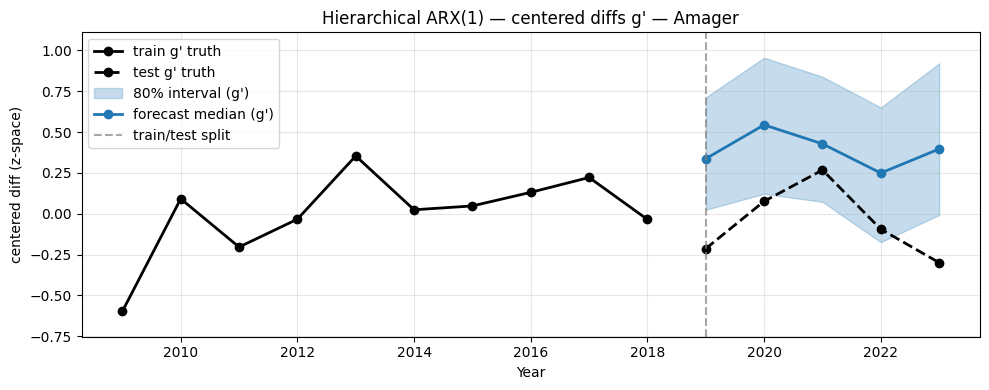

Amager 2019 centered-diff error (forecast - truth): +0.5501
Amager 2020 centered-diff error (forecast - truth): +0.4675
Amager 2021 centered-diff error (forecast - truth): +0.1598
Amager 2022 centered-diff error (forecast - truth): +0.3437
Amager 2023 centered-diff error (forecast - truth): +0.6954


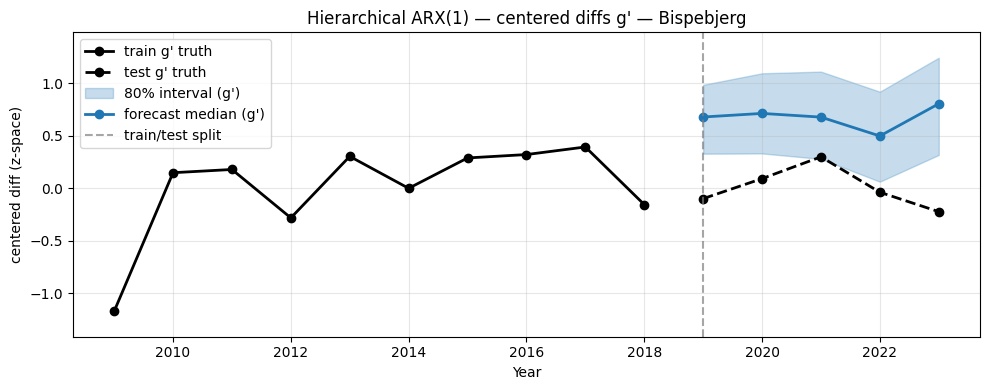

Bispebjerg 2019 centered-diff error (forecast - truth): +0.7774
Bispebjerg 2020 centered-diff error (forecast - truth): +0.6208
Bispebjerg 2021 centered-diff error (forecast - truth): +0.3783
Bispebjerg 2022 centered-diff error (forecast - truth): +0.5358
Bispebjerg 2023 centered-diff error (forecast - truth): +1.0275


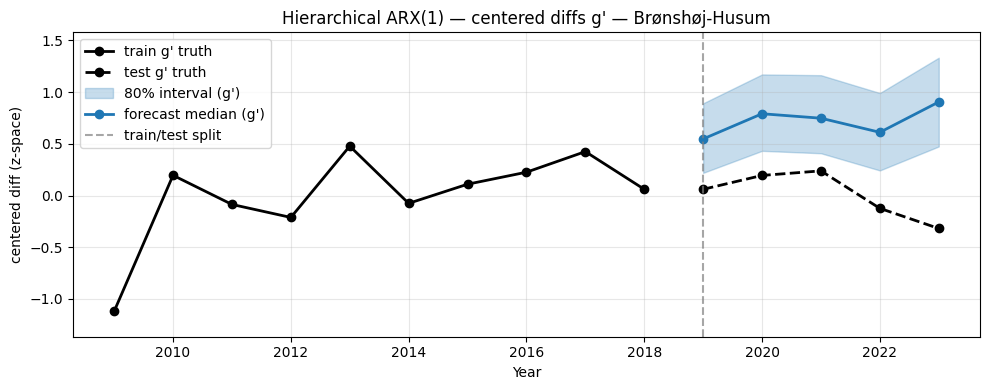

Brønshøj-Husum 2019 centered-diff error (forecast - truth): +0.4869
Brønshøj-Husum 2020 centered-diff error (forecast - truth): +0.5964
Brønshøj-Husum 2021 centered-diff error (forecast - truth): +0.5091
Brønshøj-Husum 2022 centered-diff error (forecast - truth): +0.7352
Brønshøj-Husum 2023 centered-diff error (forecast - truth): +1.2232


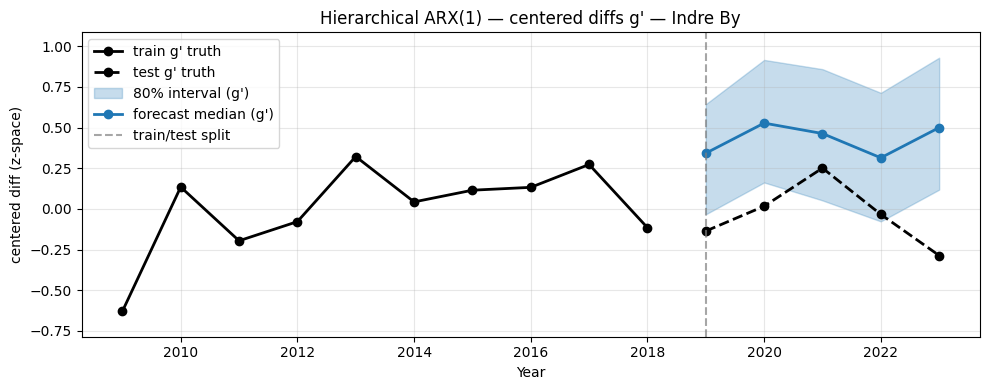

Indre By 2019 centered-diff error (forecast - truth): +0.4783
Indre By 2020 centered-diff error (forecast - truth): +0.5106
Indre By 2021 centered-diff error (forecast - truth): +0.2122
Indre By 2022 centered-diff error (forecast - truth): +0.3475
Indre By 2023 centered-diff error (forecast - truth): +0.7857


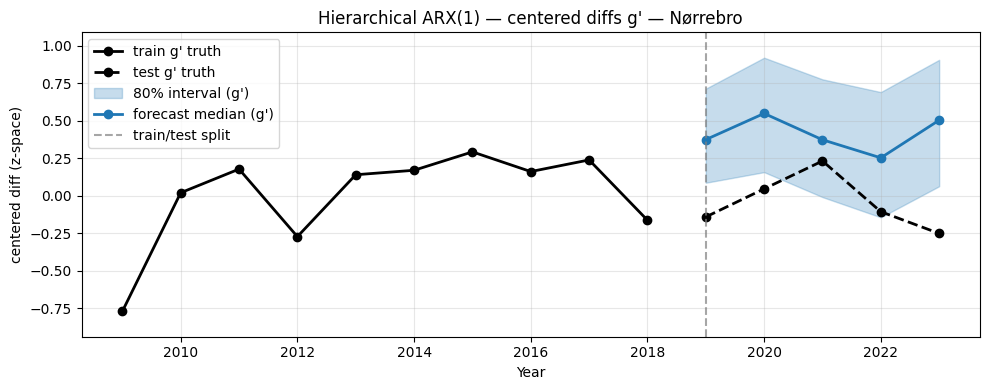

Nørrebro 2019 centered-diff error (forecast - truth): +0.5159
Nørrebro 2020 centered-diff error (forecast - truth): +0.5029
Nørrebro 2021 centered-diff error (forecast - truth): +0.1415
Nørrebro 2022 centered-diff error (forecast - truth): +0.3592
Nørrebro 2023 centered-diff error (forecast - truth): +0.7556


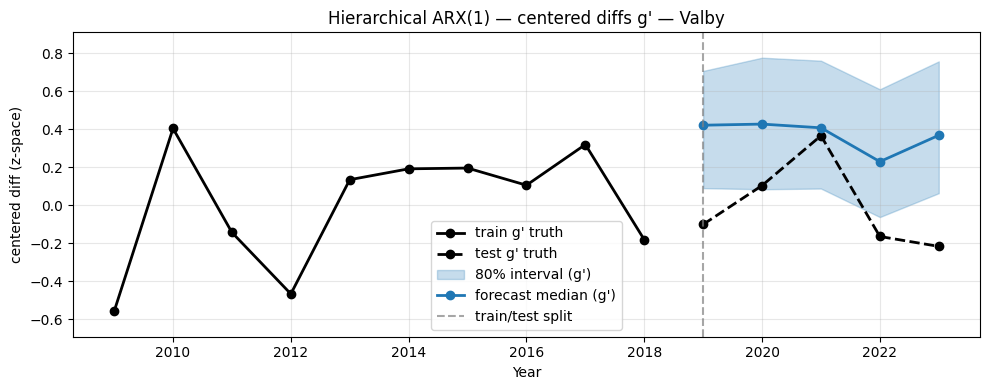

Valby 2019 centered-diff error (forecast - truth): +0.5219
Valby 2020 centered-diff error (forecast - truth): +0.3233
Valby 2021 centered-diff error (forecast - truth): +0.0416
Valby 2022 centered-diff error (forecast - truth): +0.3939
Valby 2023 centered-diff error (forecast - truth): +0.5844


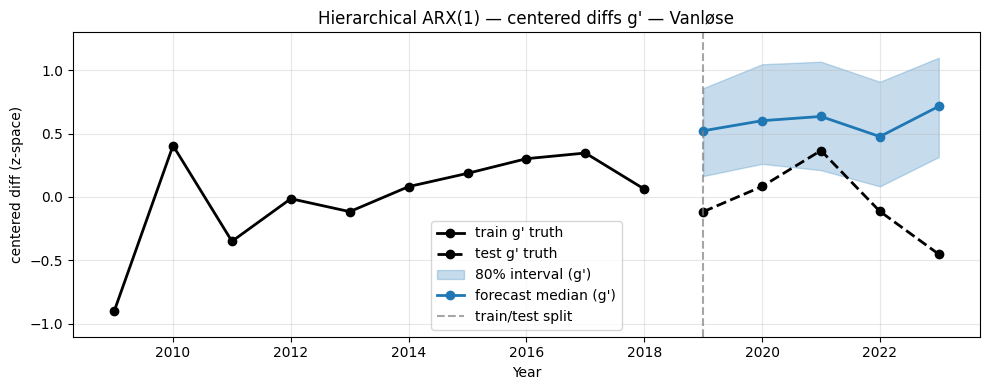

Vanløse 2019 centered-diff error (forecast - truth): +0.6387
Vanløse 2020 centered-diff error (forecast - truth): +0.5188
Vanløse 2021 centered-diff error (forecast - truth): +0.2689
Vanløse 2022 centered-diff error (forecast - truth): +0.5899
Vanløse 2023 centered-diff error (forecast - truth): +1.1666


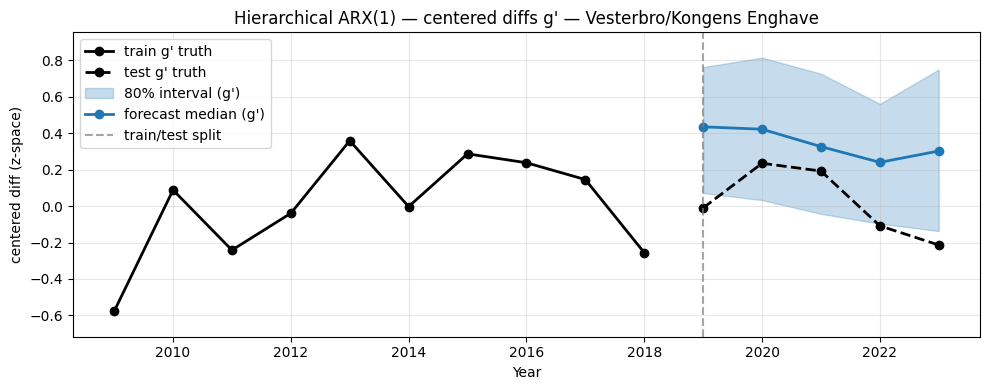

Vesterbro/Kongens Enghave 2019 centered-diff error (forecast - truth): +0.4449
Vesterbro/Kongens Enghave 2020 centered-diff error (forecast - truth): +0.1868
Vesterbro/Kongens Enghave 2021 centered-diff error (forecast - truth): +0.1341
Vesterbro/Kongens Enghave 2022 centered-diff error (forecast - truth): +0.3484
Vesterbro/Kongens Enghave 2023 centered-diff error (forecast - truth): +0.5157


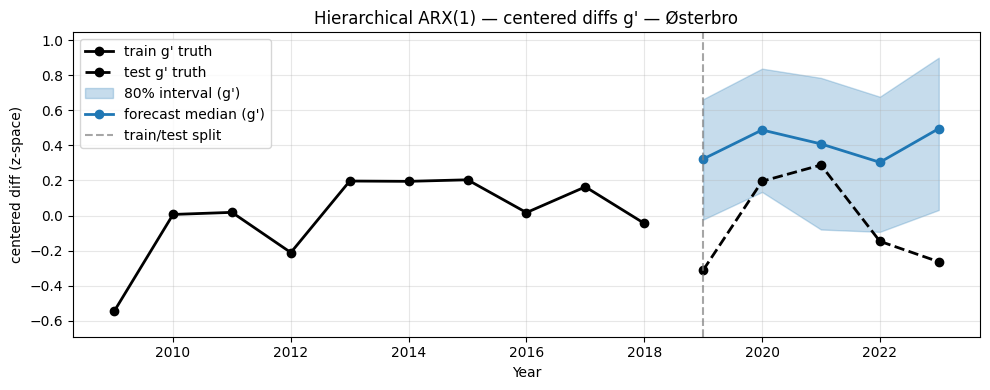

Østerbro 2019 centered-diff error (forecast - truth): +0.6334
Østerbro 2020 centered-diff error (forecast - truth): +0.2923
Østerbro 2021 centered-diff error (forecast - truth): +0.1203
Østerbro 2022 centered-diff error (forecast - truth): +0.4502
Østerbro 2023 centered-diff error (forecast - truth): +0.7587


In [42]:
import numpy as np
import pandas as pd
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import MCMC, NUTS
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1) Load feature panel (ends at 2023) and build a balanced district×year panel
# ------------------------------------------------------------
features_df = pd.read_csv("data/cleaned/model_panel_features.csv")

FEATURE_COLS_STD = [
    "total_population_std",
    "share_non_danish_std",
    "log_income_per_capita_std",
    "unemployment_rate_std",
    "avg_household_size_std",
    "year_std_std",
]

# years (model_panel_features is already restricted; Indre By ends at 2023)
years_all = np.sort(features_df["year"].unique())
# keep 2008–2023 explicitly
years_all = years_all[(years_all >= 2008) & (years_all <= 2023)]

districts = sorted(features_df["district"].unique())
D = len(districts)
K = len(FEATURE_COLS_STD)

# pivot into tensors [D, T]
T = len(years_all)

def _district_block(d):
    df_d = (
        features_df.loc[
            features_df["district"] == d,
            ["year", "median_log_sqm_price", *FEATURE_COLS_STD],
        ]
        .dropna()
        .sort_values("year")
    )
    # ensure full coverage
    df_d = df_d[df_d["year"].isin(years_all)].copy()
    if df_d["year"].nunique() != T:
        missing = sorted(set(years_all) - set(df_d["year"].unique()))
        raise ValueError(f"District {d} missing years: {missing}")
    df_d = df_d.set_index("year").loc[years_all].reset_index()
    return df_d

blocks = [_district_block(d) for d in districts]

# y: [D, T], X: [D, T, K]
y_np = np.stack([b["median_log_sqm_price"].to_numpy() for b in blocks], axis=0)
X_np = np.stack([b[FEATURE_COLS_STD].to_numpy() for b in blocks], axis=0)

y = torch.tensor(y_np, dtype=torch.float)
X = torch.tensor(X_np, dtype=torch.float)

# ------------------------------------------------------------
# 2) Per-district standardize y, then difference -> g, then train-mean center -> g'
# ------------------------------------------------------------
# split: train 2008–2018, test 2019–2023
train_end_year = 2018
train_mask = years_all <= train_end_year

idx_train_last = int(np.where(train_mask)[0][-1])  # index of 2018
idx_test_start = idx_train_last + 1                 # index of 2019

# standardize per district for stable inference
# y_z[d,t] = (y[d,t] - mean_d) / std_d

y_mean_d = y.mean(dim=1, keepdim=True)
y_std_d = y.std(dim=1, keepdim=True)
y_std_d = torch.where(y_std_d > 0, y_std_d, torch.ones_like(y_std_d))
y_z = (y - y_mean_d) / y_std_d

# diffs aligned to year t (t=1..T-1): g[d,t] = y_z[d,t] - y_z[d,t-1]
# so g has shape [D, T-1] and corresponds to years_all[1:]
g = y_z[:, 1:] - y_z[:, :-1]
X_g = X[:, 1:, :]  # align features to diff year

years_diff = years_all[1:]

# train diffs correspond to years 2009..2018 (inclusive)
train_diff_mask = years_diff <= train_end_year
Tdiff = g.shape[1]

# per-district train mean of diffs
# g_mean_diffs[d] is scalar

g_train = g[:, train_diff_mask]  # [D, Ttrain_diff]
g_mean = g_train.mean(dim=1, keepdim=True)  # [D,1]

g_c = g - g_mean  # centered diffs g' for all years

# observed g' for train and test

g_train_c = g_c[:, train_diff_mask]                       # [D, Ttrain_diff]
g_test_c = g_c[:, ~train_diff_mask]                       # [D, Ttest_diff]
X_g_train = X_g[:, train_diff_mask, :]                    # [D, Ttrain_diff, K]
X_g_test = X_g[:, ~train_diff_mask, :]                    # [D, Ttest_diff, K]

years_train_diff = years_diff[train_diff_mask]
years_test_diff = years_diff[~train_diff_mask]            # should be 2019–2023

print(f"Districts: {D}")
print(f"Years: {years_all.min()}–{years_all.max()} (T={T})")
print(f"Diff years: {years_diff.min()}–{years_diff.max()} (Tdiff={Tdiff})")
print(f"Train years (levels): 2008–{train_end_year}")
print(f"Test years  (levels): {years_all[idx_test_start]}–{years_all.max()}")
print(f"Test years  (diffs):  {int(years_test_diff.min())}–{int(years_test_diff.max())}")

# ------------------------------------------------------------
# 3) Hierarchical ARX(1) model on g'
#    g'_{d,t} = phi_d * g'_{d,t-1} + beta_d^T x_{d,t} + eps
# ------------------------------------------------------------

def hier_arx1_model(g_c_obs, X_obs):
    """g_c_obs: [D, Tdiff], X_obs: [D, Tdiff, K]"""
    D_, Tdiff_ = g_c_obs.shape
    K_ = X_obs.shape[-1]
    assert X_obs.shape[:2] == (D_, Tdiff_)
    if Tdiff_ < 2:
        raise ValueError("Need at least 2 diff observations.")

    # hyperpriors
    mu_phi = pyro.sample("mu_phi", dist.Normal(0.0, 0.5))
    sigma_phi = pyro.sample("sigma_phi", dist.HalfNormal(1.5))

    mu_beta = pyro.sample("mu_beta", dist.Normal(0.0, 0.5).expand([K_]).to_event(1))
    sigma_beta = pyro.sample(
    "sigma_beta",
    dist.HalfNormal(1.5).expand([K_]).to_event(1),
)

    # shared innovation scale
    sigma_g = pyro.sample("sigma_g", dist.HalfNormal(1.0))

    
    #plate for district 

    with pyro.plate("district", D_):
        # district-level parameters
        phi_raw_d = pyro.sample("phi_raw", dist.Normal(mu_phi, sigma_phi))
        phi_d = pyro.deterministic("phi", torch.tanh(phi_raw_d))

        beta_d = pyro.sample(
            "beta",
            dist.Normal(mu_beta, sigma_beta).to_event(1),
        )  # [D, K]

        # first time point (no lag term)
        mean0 = (X_obs[:, 0, :] * beta_d).sum(-1)
        pyro.sample("g0", dist.Normal(mean0, sigma_g), obs=g_c_obs[:, 0])

        # remaining time points
        mean = phi_d.unsqueeze(-1) * g_c_obs[:, :-1] + torch.einsum("dtk,dk->dt", X_obs[:, 1:, :], beta_d)
        pyro.sample("g1T", dist.Normal(mean, sigma_g).to_event(1), obs=g_c_obs[:, 1:])


# ------------------------------------------------------------
# 4) Fit on TRAIN ONLY
# ------------------------------------------------------------
pyro.set_rng_seed(0)
pyro.clear_param_store()

nuts = NUTS(hier_arx1_model, target_accept_prob=0.9)
# keep samples modest for runtime; increase if needed
mcmc = MCMC(nuts, num_samples=400, warmup_steps=400, num_chains=1)

mcmc.run(g_train_c, X_g_train)
post = mcmc.get_samples()

phi_post = torch.tanh(post["phi_raw"]).detach()          # [S, D]
beta_post = post["beta"].detach()                         # [S, D, K]
sig_g_post = post["sigma_g"].detach()                     # [S]

print("\nPosterior (hierarchical) summary")
print("mu_phi mean:", float(post["mu_phi"].mean()))
print("sigma_g mean:", float(sig_g_post.mean()))

# ------------------------------------------------------------
# 5) Posterior predictive on TEST (g' only), per district plot
# ------------------------------------------------------------

def simulate_g_future(phi_d, beta_d, sigma_g, g0_c, X_future):
    """Simulate centered diffs forward given X_future.
    phi_d: [D], beta_d: [D,K], g0_c: [D], X_future: [D,h,K]
    returns [D,h]
    """
    D_, h_, K_ = X_future.shape
    out = torch.empty((D_, h_), dtype=torch.float)
    prev = g0_c
    for t in range(h_):
        mean = phi_d * prev + (X_future[:, t, :] * beta_d).sum(-1)
        prev = dist.Normal(mean, sigma_g).sample()
        out[:, t] = prev
    return out

h = X_g_test.shape[1]
if h == 0:
    raise ValueError("No test diffs. Check year split.")

S = min(250, phi_post.shape[0])

# last observed train g' per district
last_train_g = g_train_c[:, -1]  # [D]

paths = []
for s in range(S):
    phi_s = phi_post[s]             # [D]
    beta_s = beta_post[s]           # [D,K]
    sig_s = sig_g_post[s]
    paths.append(simulate_g_future(phi_s, beta_s, sig_s, last_train_g, X_g_test))

paths = torch.stack(paths)  # [S, D, h]

p10 = paths.quantile(0.10, dim=0).numpy()  # [D,h]
p50 = paths.quantile(0.50, dim=0).numpy()
p90 = paths.quantile(0.90, dim=0).numpy()

# truth arrays
train_truth = g_train_c.numpy()  # [D, Ttrain_diff]
test_truth = g_test_c.numpy()    # [D, h]

for d_i, d_name in enumerate(districts):
    plt.figure(figsize=(10, 4))

    # y-limits include truth + interval to avoid clipping
    y_lo = float(min(train_truth[d_i].min(), test_truth[d_i].min(), p10[d_i].min()))
    y_hi = float(max(train_truth[d_i].max(), test_truth[d_i].max(), p90[d_i].max()))
    pad = 0.10 * (y_hi - y_lo + 1e-6)
    plt.ylim(y_lo - pad, y_hi + pad)

    # truth
    plt.plot(years_train_diff, train_truth[d_i], marker="o", color="black", linewidth=2, label="train g' truth")
    plt.plot(years_test_diff, test_truth[d_i], marker="o", color="black", linestyle="--", linewidth=2, label="test g' truth")

    # forecast
    plt.fill_between(years_test_diff, p10[d_i], p90[d_i], alpha=0.25, color="C0", label="80% interval (g')")
    plt.plot(years_test_diff, p50[d_i], marker="o", linewidth=2, color="C0", label="forecast median (g')")

    plt.axvline(years_test_diff[0], color="grey", linestyle="--", alpha=0.7, label="train/test split")

    plt.title(f"Hierarchical ARX(1) — centered diffs g' — {d_name}")
    plt.xlabel("Year")
    plt.ylabel("centered diff (z-space)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # per-year errors
    err = p50[d_i] - test_truth[d_i]
    for yr, e in zip(years_test_diff, err):
        print(f"{d_name} {int(yr)} centered-diff error (forecast - truth): {e:+.4f}")